# 1. RQ2: SINGLE CHIP VALIDATION

In [1]:
import os, sys, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from pathlib import Path
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              recall_score, confusion_matrix)

try:
    _nb = globals().get('__vsc_ipynb_file__')
    if _nb:
        os.chdir(os.path.dirname(os.path.dirname(_nb)))
except Exception:
    pass

%load_ext autoreload
%autoreload 2
import config
%matplotlib inline

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': '#e0e0e0',
    'grid.linestyle': '--',
    'grid.alpha': 0.7,
    'font.size': 10,
})
print("CWD:", os.getcwd())



[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0

CWD: /vol/bitbucket/gk225/POC_DDM/gk_code/main


In [2]:
sys.path.insert(0, 'utils')
sys.path.insert(0, 'utils/model_training')
from model_utils import build_well_stratified_random_split, build_well_stratified_nfold_splits
from sklearn.preprocessing import LabelEncoder


def load_well_ids_and_labels(exp_path):
    """y_full/well_ids_full exactly as 03_main_training.py derives them. well_ids_full
    comes from the RAW (pre label-mapping) Y_well when metadata has no well_id column --
    deliberately independent of how config.LABEL_MAPPINGS later buckets labels."""
    training_data = joblib.load(exp_path / config.TRAINING_DATA_PATH)
    Y_well = training_data["Y_well"]
    metadata_df = pd.DataFrame(training_data["metadata"])
    well_ids_full = (metadata_df["well_id"].values if "well_id" in metadata_df.columns
                      else np.array(Y_well).copy())

    label_mappings = config.get_label_mappings(exp_path)
    if exp_path.name in label_mappings:
        mapping = label_mappings[exp_path.name]
        Y_well = [mapping.get(w, w) for w in Y_well]

    y_full = LabelEncoder().fit_transform(Y_well)
    return y_full, well_ids_full


def reconstruct_well_splits(y_full, well_ids_full, mask=None, n_splits=1, random_state=0):
    """Replays evaluate_outlier_filters' own mask -> rare-class-drop -> well-stratified-split
    procedure (utils/model_training/model_utils.py:863-916) exactly, so the returned test-set
    well_ids line up with the cached y_trues_/y_preds_AC_* arrays. mask=None means the
    outlier_filter=None case (no rows removed pre-split). n_splits=1 uses the same
    max(10%, n_wells) test_size floor evaluate_outlier_filters uses for its single-split
    case; n_splits>1 returns that many well-stratified CV folds.
    Returns a list of (y_values_fold, well_ids_fold) pairs, one per fold, in the same
    order as evaluate_outlier_filters' own `splits` list."""
    if mask is None:
        mask = np.ones(len(y_full), dtype=bool)
    y_m, w_m = y_full[mask], well_ids_full[mask]

    unique_classes, class_counts = np.unique(y_m, return_counts=True)
    rare = unique_classes[class_counts < 2]
    valid = ~np.isin(y_m, rare)
    y_v, w_v = y_m[valid], w_m[valid]

    if n_splits == 1:
        n_wells = len(np.unique(w_v))
        test_size = max(len(y_v) * 0.10, n_wells) / len(y_v)
        splits = list(build_well_stratified_random_split(
            y_v, w_v, test_size=test_size, random_state=random_state).values())
    else:
        actual_splits = min(n_splits, len(np.unique(w_v)))
        splits = list(build_well_stratified_nfold_splits(
            y_v, w_v, n_splits=actual_splits, random_state=random_state).values())

    return [(y_v[test_idx], w_v[test_idx]) for _, test_idx in splits]


def remap_well_splits(well_ids_full, y_full, mask, global_splits):
    """Mirrors _remap_global_splits (utils/model_training/model_utils.py:710) plus the
    rare-class-drop step inside evaluate_outlier_filters, for the cv_splits-supplied path
    used by 04_cross_dataset_training.py's kfold/lofo modes -- where the split is computed
    ONCE on the full (unmasked) pool and then masked/remapped per outlier filter, rather
    than split fresh per filter like reconstruct_well_splits above.
    global_splits: dict or list of (train_idx, test_idx) pairs in full-pool index space.
    Returns a dict/list (matching global_splits' own container type) of
    (y_values_fold, well_ids_fold) pairs."""
    kept_global = np.where(mask)[0]
    y_m, w_m = y_full[mask], well_ids_full[mask]
    unique_classes, class_counts = np.unique(y_m, return_counts=True)
    rare = unique_classes[class_counts < 2]
    valid = ~np.isin(y_m, rare)
    kept_global = kept_global[valid]
    y_v, w_v = y_m[valid], w_m[valid]
    pos_lookup = {g: i for i, g in enumerate(kept_global)}

    def _remap_one(test_idx):
        local_test = np.array([pos_lookup[g] for g in test_idx if g in pos_lookup], dtype=int)
        return y_v[local_test], w_v[local_test]

    if isinstance(global_splits, dict):
        return {k: _remap_one(test_idx) for k, (_, test_idx) in global_splits.items()}
    return [_remap_one(test_idx) for _, test_idx in global_splits]


def well_level_accuracy(y_trues_flat, preds_flat, well_ids_test):
    """Majority-votes each well's pixel predictions into one verdict; accuracy over wells.
    The true label per well should be unanimous (one well = one label) -- a mismatch
    there signals a split-reconstruction bug, not real label noise."""
    wells = np.unique(well_ids_test)
    n_true_mismatch = 0
    correct = 0
    for w in wells:
        m = well_ids_test == w
        true_vals = pd.Series(y_trues_flat[m])
        if true_vals.nunique() > 1:
            n_true_mismatch += 1
        true_label = true_vals.mode()[0]
        pred_label = pd.Series(preds_flat[m]).mode()[0]
        correct += int(true_label == pred_label)
    if n_true_mismatch:
        print(f"  [!] {n_true_mismatch} well(s) had a non-unanimous true label -- "
              f"split reconstruction likely mismatched training.")
    return correct / len(wells), len(wells)


def verified_well_ids(y_true_cached, folds, context=""):
    """folds: list of (y_values_fold, well_ids_fold) pairs (from reconstruct_well_splits /
    remap_well_splits), covering the same rows as y_true_cached once concatenated in fold
    order. Returns the concatenated well_ids only if the concatenated y-values match
    y_true_cached exactly (length AND values) -- otherwise warns and returns None, so a
    reconstruction bug never silently produces a wrong well_accuracy number."""
    if not folds:
        return None
    y_check = np.concatenate([y for y, _ in folds])
    well_ids = np.concatenate([w for _, w in folds])
    if len(y_check) != len(y_true_cached) or not np.array_equal(y_check, y_true_cached):
        print(f"  [!] well-id reconstruction mismatch ({context}) -- skipping well_accuracy.")
        return None
    return well_ids


def verified_well_folds(cached_y_folds, folds, context=""):
    """Per-fold version of verified_well_ids -- for compute_fold_accuracy_stats, which needs
    one well_ids array per fold (not pooled) to compute a mean/std across folds. Returns a
    list of well_ids arrays (same fold order as cached_y_folds) only if every fold's
    y-values match exactly; otherwise warns and returns None."""
    if folds is None or len(folds) != len(cached_y_folds):
        print(f"  [!] well-id reconstruction mismatch ({context}: fold count) -- skipping well_accuracy.")
        return None
    out = []
    for (y_v, w_v), yt in zip(folds, cached_y_folds):
        if len(y_v) != len(yt) or not np.array_equal(y_v, yt):
            print(f"  [!] well-id reconstruction mismatch ({context}) -- skipping well_accuracy.")
            return None
        out.append(w_v)
    return out


In [3]:
FAMILIES = [
            'cnn_gru_dual', 
            'cnn_gru_dual_attn_recon', 
            ]
# SC_LEVELS = [0, 1, 2, 3]
SC_LEVELS = [0]

MODEL_KEY = {
    (fam, 0): fam for fam in FAMILIES
}
MODEL_KEY.update({
    ('cnn_gru_dual', 1):              'cnn_gru_dual_supcon',
    ('cnn_gru_dual_attn_recon', 1):   'cnn_gru_dual_attn_recon_supcon',
})

MODELS = [MODEL_KEY[(fam, sc)] for sc in SC_LEVELS for fam in FAMILIES]
MODEL_TO_FAMILY = {MODEL_KEY[(fam, sc)]: fam for sc in SC_LEVELS for fam in FAMILIES}
MODEL_TO_SC = {MODEL_KEY[(fam, sc)]: sc for sc in SC_LEVELS for fam in FAMILIES}

# ── Paths ─────────────────────────────────────────────────────────────────────
def list_folders(exp_folder):
    out = []
    for name in sorted(os.listdir(exp_folder)):
        p = os.path.join(exp_folder, name)
        if (os.path.isdir(p) and name not in config.EXCLUDED_FOLDERS
                and os.path.exists(os.path.join(p, config.TRAINING_DATA_PATH))):
            # out.append((name, p))
            out.append(name)
    return out

PREP_DIRS = {
    'nc_subtract': '/vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final_nc_subtract',
}
CURVE_JLIB = {
    'ori':          'Ori Curves',
    'ori_norm':     'Ori Curves Norm',
    'sgp4':         'Ori Curves Sg P4',
    'sgp4_norm':    'Ori Curves Sg P4 Norm',
}

TARGET_FOLDERS = list_folders(PREP_DIRS['nc_subtract'])[:]

def short_name(folder):
    return folder.split('_U_', 1)[1][:-3]

DATASET_NAMES = [short_name(f) for f in TARGET_FOLDERS]

# ── Labels ────────────────────────────────────────────────────────────────────
# Standard model naming, shared across every section of this notebook (RQ2, RQ3.1, RQ3.2)
# and mirrored verbatim in 0_LOFO_INSPECTION.ipynb -- the single source of truth for how a
# model key is displayed on any chart.
FAMILY_LABELS = {
    'cnn_gru_dual': 'CNN-BiGRU',
    'cnn_gru_dual_dann': 'CNN-BiGRU\n+ DANN',
    'cnn_gru_dual_coral': 'CNN-BiGRU\n+ CORAL',
    'cnn_gru_dual_supcon': 'CNN-BiGRU\n+ Contrastive Loss (SC1)',
    'cnn_gru_dual_supcon3': 'CNN-BiGRU\n+ Contrastive Loss (SC3)',
    'cnn_gru_dual_pc_recenter': 'CNN-BiGRU\n+ Latent Alignment',

    'cnn_gru_dual_attn_recon':   'CNN-BiGRU + Spatial Attn',
    'cnn_gru_dual_attn_recon_dann': 'CNN-BiGRU + Spatial Attn\n+ DANN',
    'cnn_gru_dual_attn_recon_coral': 'CNN-BiGRU + Spatial Attn\n+ CORAL',
    'cnn_gru_dual_attn_recon_supcon': 'CNN-BiGRU + Spatial Attn\n+ Contrastive Loss (SC1)',
    'cnn_gru_dual_attn_recon_supcon3': 'CNN-BiGRU + Spatial Attn\n+ Contrastive Loss (SC3)',
    'cnn_gru_dual_attn_recon_pc_recenter': 'CNN-BiGRU + Spatial Attn\n+ Latent Alignment',

    'cnn_gru_dual_cosine_recon': 'CNN-BiGRU + Cosine Recon',
    'ccgd_arch_poc_st': 'CCGD-ST',
    'gnn_gat': 'GNN (GAT)',
    'gnn_gat_dann': 'GNN (GAT)\n+ DANN',
    'gnn_gat_coral': 'GNN (GAT)\n+ CORAL',
    'gnn_gat_supcon': 'GNN (GAT)\n+ Contrastive Loss (SC1)',
    'gnn_gat_supcon3': 'GNN (GAT)\n+ Contrastive Loss (SC3)',

}
SC_LABELS   = {0: 'SC0', 1: 'SC1', 2: 'SC2', 3: 'SC3'}
PREP_LABELS = {'original': 'Original', 'nc_subtract': 'NC-Subtract'}
CURVE_LABELS = {'ori': 'Ori (raw)', 'ori_norm': 'Ori (norm)',
                'avg': 'Moving Avg', 'avg_norm': 'Moving Avg (norm)',
                'wavelet': 'Wavelet sym8', 'wavelet_norm': 'Wavelet sym8 (norm)',
                'bior35': 'Wavelet bior3.5', 'bior35_norm': 'Wavelet bior3.5 (norm)',
                'sgp4': 'SG p=4 (auto-w)', 'sgp4_norm': 'SG p=4 (norm)'}
METRIC_LABELS = {
    'accuracy':    'Accuracy',
    'f1':          'F1 macro',
    'auc':         'AUC-ROC',
    'sensitivity': 'Sensitivity',
    'specificity': 'Specificity',
}
METRICS = list(METRIC_LABELS)

# ── Colors ────────────────────────────────────────────────────────────────────
FAMILY_COLORS = {
    'cnn_gru_dual':              '#1f77b4',
    'cnn_gru_dual_cosine_recon': '#2ca02c',
    'cnn_gru_dual_attn_recon':   '#d62728',
    'ccgd_arch_poc_st':          '#9467bd',
}
SC_MARKERS = {0: 'o', 1: 's', 2: '^', 3: 'D'}
SC_LINES   = {0: '-', 1: '--', 2: ':', 3: '-.'}
PREP_COLORS  = {'original': '#4393c3', 'nc_subtract': '#d6604d'}
CURVE_COLORS = {
                'ori': '#4393c3', 'ori_norm': '#a6cee3',
                'avg': '#e08c00', 'avg_norm': '#f4b183',
                'wavelet': '#1a9850', 'wavelet_norm': '#a6d96a',
                'bior35': '#d6604d', 'bior35_norm': '#f4a582',
                'sgp4': '#7b2d8b', 'sgp4_norm': '#c994c7'
                }
# dataviz-skill validated categorical palette, assigned in a `models`-list's order --
# shared by every grouped-bar-by-model chart in this notebook (RQ2 and RQ3.1 alike).
PALETTE = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100',
           '#e87ba4', '#008300', '#4a3aa7', '#e34948']

print(f"{len(MODELS)} models defined.")
print("  " + "\n  ".join(MODELS))


2 models defined.
  cnn_gru_dual
  cnn_gru_dual_attn_recon


In [4]:
TARGET_FOLDERS

['D20260806_E00_C00_F4500KHz_U_DDM_01_06',
 'D20260807_E00_C00_F4500KHz_U_DDM_02_07',
 'D20260808_E00_C00_F4500KHz_U_DDM_03_01',
 'D20260810_E00_C00_F4500KHz_U_DDM_04_01',
 'D20260825_E00_C00_F4500KHz_U_DDM_05_01',
 'D20260825_E00_C00_F4500KHz_U_DDM_06_02',
 'D20260827_E00_C00_F4500KHz_U_DDM_01_final_final',
 'D20260827_E00_C00_F4500KHz_U_DDM_02_final_final',
 'D20260827_E00_C00_F4500KHz_U_DDM_03_final_final',
 'D20260827_E00_C00_F4500KHz_U_DDM_04_final_final']

In [5]:
def compute_metrics(perf, model_key, well_ids=None):
    """Return dict with accuracy/f1/auc/sensitivity/specificity, or None if missing.
    well_ids (optional): array aligned 1:1 with concatenate(perf['y_trues_']) -- adds
    well_accuracy/n_wells (majority-vote-per-well accuracy) alongside the pixel-level
    metrics above. Pass an already length/value-verified array (see verified_well_ids)."""
    pred_k = f'y_preds_AC_{model_key}_'
    prob_k = f'y_probs_AC_{model_key}_'
    if pred_k not in perf:
        return None

    y_true  = np.concatenate(perf['y_trues_'])
    y_pred  = np.concatenate(perf[pred_k])
    y_probs = np.concatenate(perf[prob_k]) if prob_k in perf else None
    n_cls   = len(np.unique(y_true))

    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    sens = recall_score(y_true, y_pred, average='macro', zero_division=0)

    if y_probs is not None and n_cls > 1:
        try:
            auc = roc_auc_score(y_true, y_probs, multi_class='ovr', average='macro')
        except Exception:
            auc = np.nan
    else:
        auc = np.nan

    # Specificity = TN/(TN+FP) per class, macro-averaged
    cm = confusion_matrix(y_true, y_pred)
    specs = []
    for i in range(n_cls):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - cm[i, :].sum() - fp
        specs.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)

    out = {'accuracy': acc, 'f1': f1, 'auc': auc,
           'sensitivity': sens, 'specificity': float(np.mean(specs))}

    if well_ids is not None:
        well_acc, n_wells = well_level_accuracy(y_true, y_pred, well_ids)
        out['well_accuracy'] = well_acc
        out['n_wells'] = n_wells

    return out


In [6]:
def macro_f1_sens_spec(y_true, y_pred):
    """F1/sensitivity (recall) macro-averaged, plus specificity (TN/(TN+FP) per class,
    macro-averaged) -- the exact computation compute_metrics uses on a single pooled
    split, factored out so compute_fold_accuracy_stats/load_cv_accuracy can call it once
    per fold instead (giving a real mean/std across folds rather than one pooled value)."""
    n_cls = len(np.unique(y_true))
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    sens = recall_score(y_true, y_pred, average='macro', zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    specs = []
    for i in range(n_cls):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - cm[i, :].sum() - fp
        specs.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)
    return f1, sens, float(np.mean(specs))


In [7]:
def load_all():
    rows = []
    for folder in TARGET_FOLDERS:
        dataset = short_name(folder)
        for prep, base_dir in PREP_DIRS.items():
            path = Path(base_dir) / folder / 'classification_performances.joblib'
            if not path.exists():
                print(f'[WARN] missing {path}')
                continue
            data = joblib.load(path)

            exp_path = Path(base_dir) / folder
            try:
                y_full, well_ids_full = load_well_ids_and_labels(exp_path)
                well_folds = reconstruct_well_splits(y_full, well_ids_full, mask=None, n_splits=1)
            except Exception as e:
                print(f'  [!] {folder}: could not reconstruct well_ids ({e}) -- well_accuracy skipped.')
                well_folds = None

            for curve, jlib_key in CURVE_JLIB.items():
                perf = data.get(jlib_key, {}).get('Native', {}).get(None)
                if perf is None:
                    continue
                # Prefer well_ids_test_ (saved directly by evaluate_outlier_filters -- see
                # utils/model_training/model_utils.py) over replaying the split -- no
                # reconstruction needed once a curve/dataset has been (re)run with the new code.
                saved_well_ids = perf.get('well_ids_test_')
                if saved_well_ids is not None:
                    well_ids = np.concatenate(saved_well_ids)
                else:
                    well_ids = (verified_well_ids(np.concatenate(perf['y_trues_']), well_folds,
                                                  context=f'{folder}/{curve}')
                               if well_folds is not None else None)
                for model in MODELS:
                    m = compute_metrics(perf, model, well_ids=well_ids)
                    if m is None:
                        continue
                    rows.append(dict(dataset=dataset, preprocessing=prep,
                                     curve_type=curve, model=model,
                                     family=MODEL_TO_FAMILY[model],
                                     sc_level=MODEL_TO_SC[model], **m))
    return pd.DataFrame(rows)

df = load_all()
print(f"Loaded {len(df)} rows  |  "
      f"{df.dataset.nunique()} datasets  "
      f"{df.preprocessing.nunique()} preprocessing  "
      f"{df.curve_type.nunique()} curve types  "
      f"{df.model.nunique()} models")
df.head(4)


  [!] well-id reconstruction mismatch (D20260806_E00_C00_F4500KHz_U_DDM_01_06/ori_norm) -- skipping well_accuracy.
  [!] well-id reconstruction mismatch (D20260806_E00_C00_F4500KHz_U_DDM_01_06/sgp4_norm) -- skipping well_accuracy.
  [!] well-id reconstruction mismatch (D20260807_E00_C00_F4500KHz_U_DDM_02_07/ori) -- skipping well_accuracy.
  [!] well-id reconstruction mismatch (D20260807_E00_C00_F4500KHz_U_DDM_02_07/ori_norm) -- skipping well_accuracy.
  [!] well-id reconstruction mismatch (D20260807_E00_C00_F4500KHz_U_DDM_02_07/sgp4_norm) -- skipping well_accuracy.
  [!] well-id reconstruction mismatch (D20260808_E00_C00_F4500KHz_U_DDM_03_01/ori) -- skipping well_accuracy.
  [!] well-id reconstruction mismatch (D20260808_E00_C00_F4500KHz_U_DDM_03_01/ori_norm) -- skipping well_accuracy.
  [!] well-id reconstruction mismatch (D20260808_E00_C00_F4500KHz_U_DDM_03_01/sgp4_norm) -- skipping well_accuracy.
  [!] well-id reconstruction mismatch (D20260810_E00_C00_F4500KHz_U_DDM_04_01/ori_norm)

,dataset,preprocessing,curve_type,model,family,sc_level,accuracy,f1,auc,sensitivity,specificity,well_accuracy,n_wells
0,DDM_01,nc_subtract,ori,cnn_gru_dual,cnn_gru_dual,0,0.930393,0.913073,0.992633,0.912648,0.986108,1.0,8.0
1,DDM_01,nc_subtract,ori,cnn_gru_dual_attn_recon,cnn_gru_dual_attn_recon,0,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,8.0
2,DDM_01,nc_subtract,ori_norm,cnn_gru_dual,cnn_gru_dual,0,0.940209,0.924441,0.996013,0.920385,0.984448,NaN,NaN
3,DDM_01,nc_subtract,ori_norm,cnn_gru_dual_attn_recon,cnn_gru_dual_attn_recon,0,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,NaN


In [8]:
expected = len(MODELS)
check = (df.groupby(['dataset','preprocessing','curve_type'])
           .size()
           .reset_index(name='n')
           .assign(expected=expected, ok=lambda x: x.n == x.expected))
missing = check[~check.ok]
if missing.empty:
    print("All combinations fully populated.")
else:
    print("[!] Incomplete combinations:")
    display(missing)


All combinations fully populated.


In [9]:
datasets = df.dataset.unique()
CURVE_ORDER = list(CURVE_JLIB.keys())   # ['ori', 'avg', 'wavelet', 'bior35', 'sgp4']

for _FILTER_DATASET in datasets:
    print(f"===+++++++++++===")
    print(f"=== {_FILTER_DATASET} ===")
    print(f"===+++++++++++===")
    for _FILTER_PREP in df.preprocessing.unique():
        _sub = df[(df.dataset == _FILTER_DATASET) & (df.preprocessing == _FILTER_PREP)].copy()
        if _sub.empty:
            continue
        _sub['SC']     = _sub.sc_level.map(SC_LABELS)
        _sub['Family'] = _sub.family.map(FAMILY_LABELS)

        # Pivot: rows = (SC, Family), outer cols = metric, inner cols = curve_type
        _pivot = (
            _sub.set_index(['SC', 'Family', 'curve_type'])[METRICS]
            .stack()
            .rename('val')
            .reset_index()
            .pivot_table(index=['SC', 'Family'],
                        columns=['level_3', 'curve_type'],
                        values='val')
        )

        _curve_order  = [c for c in CURVE_ORDER if c in _sub.curve_type.unique()]
        _metric_order = METRICS
        _pivot = _pivot.reindex(
            columns=pd.MultiIndex.from_product([_metric_order, _curve_order])
        )
        _pivot.columns = pd.MultiIndex.from_tuples(
            [(METRIC_LABELS[m], CURVE_LABELS[c]) for m, c in _pivot.columns]
        )

        # Preserve SC / Family display order
        _sc_order  = [SC_LABELS[s]  for s in SC_LEVELS]
        _fam_order = [FAMILY_LABELS[f] for f in FAMILIES]
        _pivot = _pivot.reindex(
            pd.MultiIndex.from_product([_sc_order, _fam_order], names=['SC', 'Family'])
        )

        _pivot_pct = (_pivot * 100).round(2)

        def _col_gradient(col):
            mn, mx = col.min(), col.max()
            rng = mx - mn if mx > mn else 1e-9
            return [f'background-color: rgba(26,152,80,{0.12 + 0.72*(v - mn)/rng:.2f})'
                    for v in col]

        def _metric_borders(styler):
            for mi in range(len(_metric_order) - 1):
                last_col = (mi + 1) * len(_curve_order) - 1
                styler = styler.set_properties(
                    subset=pd.IndexSlice[:, _pivot_pct.columns[last_col]],
                    **{'border-right': '2px solid #555'}
                )
            return styler

        styled = (
            _pivot_pct.style
            .apply(_col_gradient, axis=0)
            .format("{:.2f}%")
            .set_caption(
                f"{_FILTER_DATASET}  |  {PREP_LABELS[_FILTER_PREP]}  "
                f"|  columns: metric → curve type"
            )
        )
        styled = _metric_borders(styled)
        display(styled)

===+++++++++++===
=== DDM_01 ===
===+++++++++++===


===+++++++++++===
=== DDM_02 ===
===+++++++++++===


===+++++++++++===
=== DDM_03 ===
===+++++++++++===


===+++++++++++===
=== DDM_04 ===
===+++++++++++===


In [10]:
def plot_accuracy_by_model(df, models, prep='nc_subtract', curve='ori', value_col='accuracy',
                           value_label=None, figsize=(6, 4)):
    """Grouped bar chart: x=dataset, one sub-bar per model (order = `models`), y=value_col
    (accuracy% by default -- pass value_col='well_accuracy' for majority-vote well-level
    accuracy instead of pixel-level)."""
    sub = df[(df.preprocessing == prep) & (df.curve_type == curve)]
    datasets = DATASET_NAMES
    n_models = len(models)
    bar_w = 0.8 / n_models
    x = np.arange(len(datasets))
    ylabel = value_label or f'{value_col.replace("_", " ").title()} (%)'

    fig, ax = plt.subplots(figsize=figsize)
    for mi, model in enumerate(models):
        ys = np.array([
            (sub[(sub.dataset == ds) & (sub.model == model)][value_col].iloc[0] * 100
             if not sub[(sub.dataset == ds) & (sub.model == model)].empty else np.nan)
            for ds in datasets
        ])
        offset = (mi - (n_models - 1) / 2) * bar_w
        ax.bar(x + offset, np.nan_to_num(ys, nan=0), width=bar_w,
               color=PALETTE[mi % len(PALETTE)],
               label=FAMILY_LABELS.get(model, model),
               edgecolor='white', linewidth=0.8)
        for xi, yi in zip(x + offset, ys):
            if not np.isnan(yi):
                ax.text(xi, yi + 0.5, f'{yi:.2f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(datasets)
    ax.set_xlabel('Dataset')
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 108)
    ax.legend(fontsize=8, loc='lower right', framealpha=0.9, bbox_to_anchor=(1.5,0))
    # ax.set_title(f'Accuracy by dataset and model  |  {PREP_LABELS[prep]}  |  {CURVE_LABELS[curve]}',
                #  fontsize=11, fontweight='bold')
    fig.tight_layout()
    plt.show()


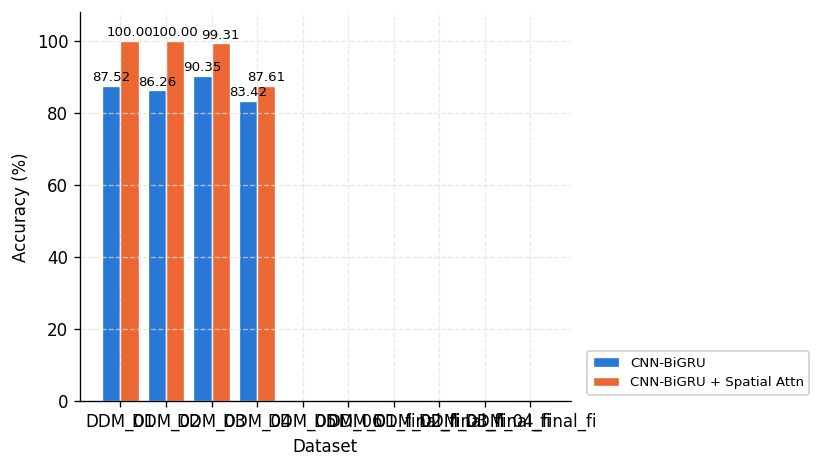

In [11]:
plot_accuracy_by_model(df, ['cnn_gru_dual', 'cnn_gru_dual_attn_recon'], curve='sgp4_norm', figsize=(8, 4))

In [12]:
# plot_accuracy_by_model(df, ['cnn_gru_dual', 'cnn_gru_dual_attn_recon'], curve='sgp4_norm',
#                        value_col='well_accuracy', figsize=(8, 4))


# 1b. RQ2b: PER-FOLD OUTLIER-FILTER ABLATION (Ablation 6)

Reads `ablations/ablation6_chip_outlier_model_ablation_performances.joblib` per chip --
a separate 5-fold CV run (`ablation6_chip_outlier_model_ablation.py`, `ori_curve_sg_p4_norm`)
comparing 3 models x 3 outlier filters, distinct from RQ2's single-split `classification_performances.joblib` above.

In [13]:
ABL6_MODELS = ['cnn_gru_dual', 'cnn_gru_dual_attn_recon', 'gnn_gat']
ABL6_CURVE_TYPE = 'sgp4_norm'
ABL6_FILTERS = [None, 'amf_label_amf_send_5', f'lstm_ae_glb_ds{config.AE_DOWNSAMPLE_FACTOR}_label_elbow']
ABL6_FILTER_LABELS = {
    None: 'None',
    'amf_label_amf_send_5': 'AMF',
    f'lstm_ae_glb_ds{config.AE_DOWNSAMPLE_FACTOR}_label_elbow': 'LSTM-AE',
}

print(f"{len(ABL6_MODELS)} models x {len(ABL6_FILTERS)} filters defined.")

3 models x 3 filters defined.


In [14]:
def compute_fold_accuracy_stats(perf, model_key, well_ids_folds=None):
    """Mean/std accuracy ACROSS folds (not pooled) -- matches ablation6_chip_outlier_model_ablation.py's
    own '86.85% ± 0.49%' log line exactly (utils/model_training/model_utils.py:2476-2486):
    one accuracy_score() per fold, then np.mean/np.std (ddof=0) across those fold-level numbers.
    F1/sensitivity/specificity get the same per-fold-then-mean/std treatment (via
    macro_f1_sens_spec), unlike compute_metrics' pooled versions of those three.
    well_ids_folds (optional): list of well_ids arrays, one per fold, same order/length as
    perf['y_trues_'] -- adds the well-level equivalent (well_accuracy_mean/std)."""
    pred_k = f'y_preds_AC_{model_key}_'
    if pred_k not in perf:
        return None
    fold_accs = [accuracy_score(yt, yp) for yt, yp in zip(perf['y_trues_'], perf[pred_k])]
    out = {'accuracy_mean': np.mean(fold_accs) * 100, 'accuracy_std': np.std(fold_accs) * 100}

    fold_f1s, fold_senss, fold_specs = [], [], []
    for yt, yp in zip(perf['y_trues_'], perf[pred_k]):
        f1, sens, spec = macro_f1_sens_spec(yt, yp)
        fold_f1s.append(f1); fold_senss.append(sens); fold_specs.append(spec)
    out['f1_mean'] = np.mean(fold_f1s) * 100;             out['f1_std'] = np.std(fold_f1s) * 100
    out['sensitivity_mean'] = np.mean(fold_senss) * 100;  out['sensitivity_std'] = np.std(fold_senss) * 100
    out['specificity_mean'] = np.mean(fold_specs) * 100;  out['specificity_std'] = np.std(fold_specs) * 100

    if well_ids_folds is not None:
        fold_well_accs = []
        for yt, yp, w in zip(perf['y_trues_'], perf[pred_k], well_ids_folds):
            wa, _ = well_level_accuracy(yt, yp, w)
            fold_well_accs.append(wa)
        out['well_accuracy_mean'] = np.mean(fold_well_accs) * 100
        out['well_accuracy_std'] = np.std(fold_well_accs) * 100
    return out


_ABL6_ARRAYS_CACHE = {}

def _abl6_training_arrays(exp_path):
    """y_full/well_ids_full/features_df exactly as ablation6_chip_outlier_model_ablation.py's
    run_one() derives them for ABL6_CURVE_TYPE, cached per exp_path (training_data is large
    and every filter for a given folder needs the same arrays)."""
    if exp_path in _ABL6_ARRAYS_CACHE:
        return _ABL6_ARRAYS_CACHE[exp_path]
    training_data = joblib.load(exp_path / config.TRAINING_DATA_PATH)
    dataset_name = list(training_data["dataset_name"])
    kinetic_features = training_data["kinetic_features"]
    Y_well = training_data["Y_well"]

    keep = [i for i, n in enumerate(dataset_name)
            if not n.startswith("avg_") and not n.startswith("original_fitted_stretched")]
    dataset_name = [dataset_name[i] for i in keep]
    kinetic_features = [kinetic_features[i] for i in keep]

    metadata_df = pd.DataFrame(training_data["metadata"])
    well_ids_full = (metadata_df["well_id"].values if "well_id" in metadata_df.columns
                      else np.array(Y_well).copy())

    label_mappings = config.get_label_mappings(exp_path)
    if exp_path.name in label_mappings:
        mapping = label_mappings[exp_path.name]
        Y_well = [mapping.get(w, w) for w in Y_well]
    y_full = LabelEncoder().fit_transform(Y_well)

    target_name = config.CURVE_TYPE_ALIASES.get(ABL6_CURVE_TYPE, ABL6_CURVE_TYPE)
    result = ((y_full, well_ids_full, kinetic_features[dataset_name.index(target_name)])
              if target_name in dataset_name else (None, None, None))
    _ABL6_ARRAYS_CACHE[exp_path] = result
    return result


def abl6_well_folds(exp_path, filt):
    y_full, well_ids_full, features_df = _abl6_training_arrays(exp_path)
    if y_full is None:
        return None
    if filt is None:
        mask = np.ones(len(y_full), dtype=bool)
    elif filt not in features_df.columns:
        return None
    else:
        mask = (features_df[filt] == 1).fillna(False).values
    return reconstruct_well_splits(y_full, well_ids_full, mask=mask, n_splits=5)


def load_ablation6_all():
    rows = []
    for folder in TARGET_FOLDERS:
        dataset = short_name(folder)
        exp_path = Path(PREP_DIRS['nc_subtract']) / folder
        path = exp_path / 'ablations' / 'ablation6_chip_outlier_model_ablation_performances.joblib'
        if not path.exists():
            print(f'[WARN] missing {path}')
            continue
        data = joblib.load(path)
        for filt in ABL6_FILTERS:
            perf = data.get(filt)
            if perf is None:
                continue
            well_folds = abl6_well_folds(exp_path, filt)
            for model in ABL6_MODELS:
                m = compute_metrics(perf, model)
                if m is None:
                    continue
                # Prefer well_ids_test_ (see load_all's comment above) over replaying the split.
                saved_well_ids_folds = perf.get('well_ids_test_')
                if saved_well_ids_folds is not None:
                    well_ids_folds = saved_well_ids_folds
                elif well_folds is not None:
                    well_ids_folds = verified_well_folds(perf['y_trues_'], well_folds,
                                                         context=f'{folder}/{filt}/{model}')
                else:
                    well_ids_folds = None
                stats = compute_fold_accuracy_stats(perf, model, well_ids_folds=well_ids_folds)
                rows.append(dict(dataset=dataset, outlier_filter=filt, model=model, **stats, **m))
    return pd.DataFrame(rows)

abl6_df = load_ablation6_all()
print(f"Loaded {len(abl6_df)} rows  |  "
      f"{abl6_df.dataset.nunique()} datasets  "
      f"{abl6_df.outlier_filter.nunique(dropna=False)} filters  "
      f"{abl6_df.model.nunique()} models")
abl6_df.head(8)


[WARN] missing /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final_nc_subtract/D20260825_E00_C00_F4500KHz_U_DDM_06_02/ablations/ablation6_chip_outlier_model_ablation_performances.joblib
[WARN] missing /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final_nc_subtract/D20260827_E00_C00_F4500KHz_U_DDM_01_final_final/ablations/ablation6_chip_outlier_model_ablation_performances.joblib
[WARN] missing /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final_nc_subtract/D20260827_E00_C00_F4500KHz_U_DDM_02_final_final/ablations/ablation6_chip_outlier_model_ablation_performances.joblib
[WARN] missing /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final_nc_subtract/D20260827_E00_C00_F4500KHz_U_DDM_03_final_final/ablations/ablation6_chip_outlier_model_ablation_performances.joblib
[WARN] missing /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final_nc_subtract/D20260827_E00_C00_F4500KHz_U_DDM_04_final_final/ablations/ablation6_chip_outlier_model_ablation_performances.joblib
Loaded 37 rows  |  5 datasets  3 f

,dataset,outlier_filter,model,accuracy_mean,accuracy_std,f1_mean,f1_std,sensitivity_mean,sensitivity_std,specificity_mean,specificity_std,well_accuracy_mean,well_accuracy_std,accuracy,f1,auc,sensitivity,specificity
0,DDM_01,None,cnn_gru_dual,86.854646,0.485546,83.954092,0.564151,83.608455,0.536051,97.285251,0.117986,100.0,0.0,0.868546,0.839531,0.978432,0.836086,0.972853
1,DDM_01,None,cnn_gru_dual_attn_recon,99.276257,0.428136,99.112539,0.548747,99.115099,0.547263,99.858673,0.081083,100.0,0.0,0.992762,0.991128,0.999812,0.991151,0.998587
2,DDM_01,None,gnn_gat,98.642076,0.612416,98.270772,0.751019,98.284916,0.844064,99.728376,0.128613,100.0,0.0,0.986420,0.982710,0.998973,0.982846,0.997284
3,DDM_01,amf_label_amf_send_5,cnn_gru_dual,87.881695,0.334778,85.512100,0.388642,85.192973,0.380701,97.521017,0.076508,NaN,NaN,0.878817,0.855252,0.981602,0.851930,0.975210
4,DDM_01,amf_label_amf_send_5,cnn_gru_dual_attn_recon,99.352518,0.205981,99.214824,0.245698,99.202143,0.238798,99.873042,0.039621,NaN,NaN,0.993525,0.992148,0.999875,0.992023,0.998730
5,DDM_01,amf_label_amf_send_5,gnn_gat,98.848921,0.376973,98.582701,0.441647,98.571647,0.444514,99.775548,0.073420,NaN,NaN,0.988489,0.985839,0.999495,0.985721,0.997756
6,DDM_01,lstm_ae_glb_ds1_label_elbow,cnn_gru_dual,87.396356,0.721416,84.728697,0.782694,84.378760,0.985686,97.392043,0.173577,NaN,NaN,0.873963,0.847424,0.980207,0.843786,0.973920
7,DDM_01,lstm_ae_glb_ds1_label_elbow,cnn_gru_dual_attn_recon,99.468010,0.327441,99.346202,0.415576,99.330603,0.413512,99.894193,0.062744,NaN,NaN,0.994680,0.993466,0.999921,0.993307,0.998942


In [15]:
abl6_expected = len(ABL6_MODELS) * len(ABL6_FILTERS)
abl6_check = (abl6_df.groupby('dataset')
                .size()
                .reset_index(name='n')
                .assign(expected=abl6_expected, ok=lambda x: x.n == x.expected))
abl6_missing = abl6_check[~abl6_check.ok]
if abl6_missing.empty:
    print("All (model, filter) combinations fully populated.")
else:
    print("[!] Incomplete combinations (job likely still running):")
    display(abl6_missing)

[!] Incomplete combinations (job likely still running):


,dataset,n,expected,ok
4,DDM_05,1,9,False


In [16]:
import colorsys
from matplotlib.colors import to_rgb


def _shade(base_rgb, frac, spread=0.6):
    """frac=1 -> lighter, frac=0 -> darker, frac=0.5 -> unchanged. Same recipe as
    0_LOFO_INSPECTION.ipynb's _shade (used there for concentration shading)."""
    h, l, s = colorsys.rgb_to_hls(*base_rgb[:3])
    l = min(0.85, max(0.15, l + (frac - 0.5) * spread))
    return colorsys.hls_to_rgb(h, l, s)


def plot_accuracy_by_model_filter(df, models, filters, filter_labels, value_col='accuracy_mean',
                                  std_col='accuracy_std', value_label=None, figsize=(16, 5.5)):
    """Grouped bar chart: x=dataset, one sub-bar per (model, filter) pair. Color=model
    (same PALETTE indexing as plot_accuracy_by_model above), shade=filter (lighter=None,
    darker=more filtering). Error bars = std across the 5 CV folds; label = mean ± std.
    value_col/std_col select which mean/std pair to plot -- pass value_col='well_accuracy_mean',
    std_col='well_accuracy_std' for majority-vote well-level accuracy instead of pixel-level."""
    datasets = DATASET_NAMES
    n_bars = len(models) * len(filters)
    bar_w = 0.8 / n_bars
    x = np.arange(len(datasets))
    ylabel = value_label or f'{value_col.replace("_mean", "").replace("_", " ").title()} (%)'

    fig, ax = plt.subplots(figsize=figsize)
    bi = 0
    for mi, model in enumerate(models):
        base_rgb = to_rgb(PALETTE[mi % len(PALETTE)])
        for fi, filt in enumerate(filters):
            frac = 1 - fi / (len(filters) - 1) if len(filters) > 1 else 0.5
            color = _shade(base_rgb, frac)
            filt_mask = df.outlier_filter.isna() if filt is None else (df.outlier_filter == filt)
            sub = df[(df.model == model) & filt_mask]
            ys, errs = [], []
            for ds in datasets:
                r = sub[sub.dataset == ds]
                if r.empty:
                    ys.append(np.nan); errs.append(np.nan)
                else:
                    ys.append(r[value_col].iloc[0]); errs.append(r[std_col].iloc[0])
            ys, errs = np.array(ys), np.array(errs)

            offset = (bi - (n_bars - 1) / 2) * bar_w
            ax.bar(x + offset, np.nan_to_num(ys, nan=0), yerr=np.nan_to_num(errs, nan=0),
                  width=bar_w, color=color, edgecolor='white', linewidth=0.5,
                  capsize=2, error_kw=dict(elinewidth=0.7, ecolor='#3a3a3a'))
            for xi, yi, ei in zip(x + offset, ys, errs):
                if not np.isnan(yi):
                    ax.text(xi, yi + ei + 0.5, f'{yi:.1f}±{ei:.1f}', ha='center', va='bottom',
                           fontsize=5.5, rotation=90)
            bi += 1

    ax.set_xticks(x)
    ax.set_xticklabels(datasets)
    ax.set_xlabel('Dataset')
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 120)

    model_handles = [plt.Line2D([0], [0], marker='s', color='w', markersize=11,
                                markerfacecolor=PALETTE[mi % len(PALETTE)], label=FAMILY_LABELS.get(m, m))
                     for mi, m in enumerate(models)]
    filter_handles = [plt.Line2D([0], [0], marker='s', color='w', markersize=11,
                                 markerfacecolor=_shade((0.5, 0.5, 0.5),
                                                        1 - fi / (len(filters) - 1) if len(filters) > 1 else 0.5),
                                 label=filter_labels[filt])
                      for fi, filt in enumerate(filters)]
    ax.legend(handles=model_handles + filter_handles, fontsize=8, ncol=2,
             loc='upper center', bbox_to_anchor=(0.5, -0.12), framealpha=0.9)
    fig.tight_layout()
    plt.show()


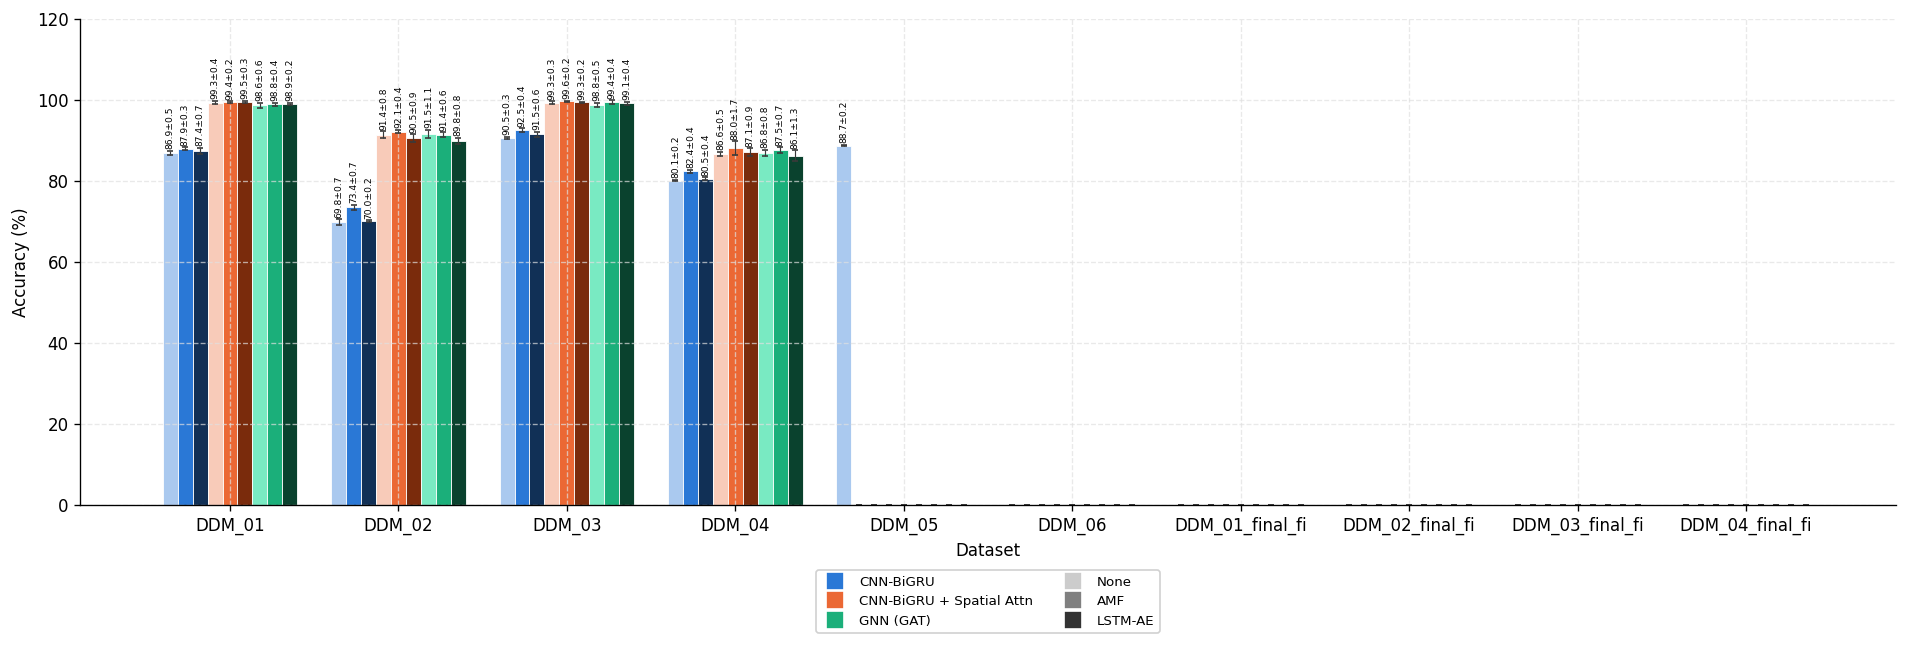

In [17]:
plot_accuracy_by_model_filter(abl6_df, ABL6_MODELS, ABL6_FILTERS, ABL6_FILTER_LABELS)

In [18]:
# plot_accuracy_by_model_filter(abl6_df, ABL6_MODELS, ABL6_FILTERS, ABL6_FILTER_LABELS,
#                               value_col='well_accuracy_mean', std_col='well_accuracy_std')


In [19]:
def plot_accuracy_by_model_abl6(df, models, filt=None, value_col='accuracy_mean', std_col='accuracy_std',
                                value_label=None, figsize=(6, 4)):
    """Grouped bar chart: x=dataset, one sub-bar per model (order = `models`) -- same layout as
    plot_accuracy_by_model, but sourced from abl6_df's 5-fold mean/std columns and restricted to
    one outlier_filter (default None/baseline) instead of one (prep, curve_type). Error bars =
    std across the 5 CV folds; pass value_col='well_accuracy_mean', std_col='well_accuracy_std'
    for majority-vote well-level accuracy instead of pixel-level."""
    filt_mask = df.outlier_filter.isna() if filt is None else (df.outlier_filter == filt)
    sub = df[filt_mask]
    datasets = DATASET_NAMES
    n_models = len(models)
    bar_w = 0.8 / n_models
    x = np.arange(len(datasets))
    ylabel = value_label or f'{value_col.replace("_mean", "").replace("_", " ").title()} (%)'

    fig, ax = plt.subplots(figsize=figsize)
    for mi, model in enumerate(models):
        ys, errs = [], []
        for ds in datasets:
            r = sub[(sub.dataset == ds) & (sub.model == model)]
            if r.empty:
                ys.append(np.nan); errs.append(np.nan)
            else:
                ys.append(r[value_col].iloc[0]); errs.append(r[std_col].iloc[0])
        ys, errs = np.array(ys), np.array(errs)

        offset = (mi - (n_models - 1) / 2) * bar_w
        ax.bar(x + offset, np.nan_to_num(ys, nan=0), yerr=np.nan_to_num(errs, nan=0),
               width=bar_w, color=PALETTE[mi % len(PALETTE)],
               label=FAMILY_LABELS.get(model, model),
               edgecolor='white', linewidth=0.8,
               capsize=3, error_kw=dict(elinewidth=0.8, ecolor='#3a3a3a'))
        for xi, yi, ei in zip(x + offset, ys, errs):
            if not np.isnan(yi):
                ax.text(xi, yi + ei + 1.5, f'{yi:.2f}\n±{ei:.2f}', ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(datasets)
    ax.set_xlabel('Dataset')
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 108)
    ax.legend(fontsize=11, framealpha=0.9, loc='upper center',
              bbox_to_anchor=(0.5, -0.22), ncol=n_models)
    fig.tight_layout()
    plt.show()


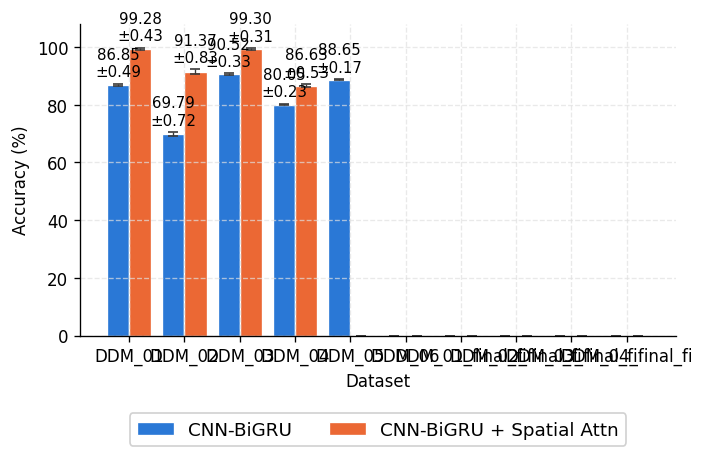

In [20]:
plot_accuracy_by_model_abl6(abl6_df, ['cnn_gru_dual', 'cnn_gru_dual_attn_recon']) #ABL6_MODELS)


### LaTeX table -- Ablation6 baseline (no outlier filter), CNN-BiGRU vs. + Spatial Attn

Single table across all 4 datasets (rows), since only 2 models are compared: columns
are grouped by model (Accuracy, F1), each mean $\pm$ std across the 5 CV folds.


In [21]:
def build_abl6_latex_table(abl6_df, filt, models, model_labels, dataset_order,
                            caption, label, bold_model=None):
    filt_mask = abl6_df.outlier_filter.isna() if filt is None else (abl6_df.outlier_filter == filt)
    sub = abl6_df[filt_mask & abl6_df.model.isin(models)]

    header_groups = ' & '.join(
        f'\\multicolumn{{2}}{{c}}{{\\textbf{{{model_labels.get(m, m).replace(chr(10), " ")}}}}}'
        for m in models)
    cmid = ' '.join(f'\\cmidrule(lr){{{2 + 2*i}-{3 + 2*i}}}' for i in range(len(models)))

    lines = [
        '\\begin{table}[htbp]',
        '    \\centering',
        f'    \\caption{{{caption}}}',
        f'    \\label{{{label}}}',
        '    \\small',
        '',
        '    \\resizebox{\\textwidth}{!}{',
        '    \\begin{tabular}{l' + 'rr' * len(models) + '}',
        '    \\toprule',
        f'     & {header_groups} \\\\',
        f'    {cmid}',
        '    \\textbf{Dataset} & ' + ' & '.join('\\textbf{Accuracy} & \\textbf{F1}' for _ in models) + ' \\\\',
        '    \\midrule',
    ]
    for ds in dataset_order:
        row = sub[sub.dataset == ds]
        cells = []
        for m in models:
            r = row[row.model == m]
            if r.empty:
                cells += ['--', '--']
                continue
            acc_c = f"{r['accuracy_mean'].iloc[0]:.2f}\\% $\\pm$ {r['accuracy_std'].iloc[0]:.2f}\\%"
            f1_c  = f"{r['f1_mean'].iloc[0]:.2f}\\% $\\pm$ {r['f1_std'].iloc[0]:.2f}\\%"
            if m == bold_model:
                acc_c, f1_c = f'\\textbf{{{acc_c}}}', f'\\textbf{{{f1_c}}}'
            cells += [acc_c, f1_c]
        lines.append(f'    {ds} & {" & ".join(cells)} \\\\')
    lines += ['    \\bottomrule', '    \\end{tabular}', '    }', '\\end{table}']
    return '\n'.join(lines)


abl6_latex = build_abl6_latex_table(
    abl6_df, filt=None,
    models=['cnn_gru_dual', 'cnn_gru_dual_attn_recon'], model_labels=FAMILY_LABELS,
    dataset_order=DATASET_NAMES, bold_model='cnn_gru_dual_attn_recon',
    caption=('5-fold ablation6 cross-validation accuracy and macro F1 per dataset '
             '(baseline, no outlier filter), reported as mean $\\pm$ standard deviation '
             'across folds. The proposed model is shown in bold.'),
    label='tab:abl6_baseline_acc_f1',
)
print(abl6_latex)


\begin{table}[htbp]
    \centering
    \caption{5-fold ablation6 cross-validation accuracy and macro F1 per dataset (baseline, no outlier filter), reported as mean $\pm$ standard deviation across folds. The proposed model is shown in bold.}
    \label{tab:abl6_baseline_acc_f1}
    \small

    \resizebox{\textwidth}{!}{
    \begin{tabular}{lrrrr}
    \toprule
     & \multicolumn{2}{c}{\textbf{CNN-BiGRU}} & \multicolumn{2}{c}{\textbf{CNN-BiGRU + Spatial Attn}} \\
    \cmidrule(lr){2-3} \cmidrule(lr){4-5}
    \textbf{Dataset} & \textbf{Accuracy} & \textbf{F1} & \textbf{Accuracy} & \textbf{F1} \\
    \midrule
    DDM_01 & 86.85\% $\pm$ 0.49\% & 83.95\% $\pm$ 0.56\% & \textbf{99.28\% $\pm$ 0.43\%} & \textbf{99.11\% $\pm$ 0.55\%} \\
    DDM_02 & 69.79\% $\pm$ 0.72\% & 62.34\% $\pm$ 0.77\% & \textbf{91.37\% $\pm$ 0.83\%} & \textbf{88.58\% $\pm$ 1.17\%} \\
    DDM_03 & 90.52\% $\pm$ 0.33\% & 90.24\% $\pm$ 0.28\% & \textbf{99.30\% $\pm$ 0.31\%} & \textbf{99.41\% $\pm$ 0.20\%} \\
    DDM_04 & 80

# 2. RQ3.1: CROSS VALIDATION

In [22]:
import importlib

# Reuse 06b's own results-file discovery instead of reimplementing it, so this
# section always matches what 06b_cross_dataset_prediction_report.py actually reads.
b06 = importlib.import_module("06b_cross_dataset_prediction_report")
# combine_group/build_nfold_splits/is_amplifying_mask -- reused as-is (not reimplemented)
# to reconstruct well_ids for well_accuracy below, so it stays exactly in sync with how
# 04_cross_dataset_training.py itself builds the kfold5 pool/splits/noamp_remove mask.
p04 = importlib.import_module("04_cross_dataset_training")

CV_EXP_FOLDER  = PREP_DIRS['nc_subtract']
CV_MODE_STR    = "kfold5"
CV_FILTER      = "noamp_remove"
CV_CURVE_TYPES = ["ori_curve_norm", "ori_curve_sg_p4_norm"]
CV_CURVE_SHORT = {"ori_curve_norm": "ori_norm", "ori_curve_sg_p4_norm": "sgp4_norm"}

def cv_group_dir(group_name):
    return Path(CV_EXP_FOLDER) / "cross_dataset_cv" / group_name

def load_cv_results(group_name, curve_type):
    group_dir = cv_group_dir(group_name)
    print(group_dir)
    legacy_path = b06.find_results_path(group_dir, CV_MODE_STR, curve_type)
    print(legacy_path)
    return b06.load_partitioned(group_dir, CV_MODE_STR, curve_type, legacy_path=legacy_path)


In [23]:
CV_MODELS = MODELS + ['gnn_gat']

def _cv_well_folds(group_name, curve_type):
    """Test-set well_ids for every fold_x of this group/curve_type's kfold5 split, mirroring
    04_cross_dataset_training.py's kfold path exactly: combine_group() -> build_nfold_splits()
    on the full unmasked pool, then remap_well_splits() through the noamp_remove mask (the
    only outlier_filter this section evaluates, CV_FILTER). Returns None if well_ids weren't
    available for this group (missing pixel coords)."""
    exp_paths = [Path(CV_EXP_FOLDER, name) for name in config.CROSS_DATASET_GROUPS[group_name]]
    combined = p04.combine_group(exp_paths, group_name, curve_type=curve_type)
    if combined is None:
        print(f"  [!] {group_name}/{curve_type}: combine_group() returned nothing -- well_accuracy skipped.")
        return None
    if combined["well_ids"] is None:
        print(f"  [!] {group_name}/{curve_type}: no pixel_row_idx/pixel_col_idx metadata (well_ids unavailable) -- well_accuracy skipped.")
        return None
    y_full = LabelEncoder().fit_transform(combined["Y_mapped"])
    cv_splits = p04.build_nfold_splits(y_full, well_ids=combined["well_ids"], n_splits=5)
    mask = (p04.is_amplifying_mask(combined["curves"]) if CV_FILTER == p04.NOAMP_FILTER_NAME
            else np.ones(len(y_full), dtype=bool))
    return remap_well_splits(combined["well_ids"], y_full, mask, cv_splits)


def load_cv_accuracy(group_indices=None):
    if group_indices is not None:
        groups = [list(config.CROSS_DATASET_GROUPS)[i] for i in group_indices]
    else:
        groups = list(config.CROSS_DATASET_GROUPS)

    rows = []
    for group_name in groups:
        for curve_type in CV_CURVE_TYPES:
            lofo_results = load_cv_results(group_name, curve_type)
            if not lofo_results:
                print(f"[WARN] No results for group {group_name} / curve {curve_type}")
                continue
            fold_labels = sorted([k for k in lofo_results if k.startswith("fold_")],
                                  key=lambda s: int(s.split("_")[1]))

            # Prefer well_ids_test_ (saved directly by evaluate_outlier_filters -- see
            # utils/model_training/model_utils.py) over replaying the split. Only pay for
            # _cv_well_folds' group-pool rebuild if at least one fold still lacks the new key.
            _needs_legacy = any(
                lofo_results[fold].get(CV_FILTER, {}).get('well_ids_test_') is None
                for fold in fold_labels if lofo_results[fold].get(CV_FILTER) is not None
            )
            well_folds = None
            if _needs_legacy:
                try:
                    well_folds = _cv_well_folds(group_name, curve_type)
                except Exception as e:
                    print(f"  [!] {group_name}/{curve_type}: could not reconstruct well_ids ({e}) -- well_accuracy skipped.")
                    well_folds = None

            for fold in fold_labels:
                res_entry = lofo_results[fold].get(CV_FILTER)
                if res_entry is None:
                    continue
                y_true_full = np.concatenate(res_entry["y_trues_"])
                saved_well_ids = res_entry.get('well_ids_test_')
                if saved_well_ids is not None:
                    well_ids_test = np.concatenate(saved_well_ids)
                else:
                    well_ids_test = (verified_well_ids(y_true_full, [well_folds[fold]],
                                                       context=f'{group_name}/{curve_type}/{fold}')
                                     if well_folds is not None and fold in well_folds else None)
                for model in CV_MODELS:
                    preds_key = config.MODEL_KEY_MAP.get(model, (None,))[0]
                    if preds_key is None or preds_key not in res_entry:
                        continue
                    y_pred = np.concatenate(res_entry[preds_key])
                    f1, sens, spec = macro_f1_sens_spec(y_true_full, y_pred)
                    row = dict(group=group_name, curve_type=CV_CURVE_SHORT.get(curve_type, curve_type),
                              fold=fold, model=model, family=MODEL_TO_FAMILY.get(model, model),
                              accuracy=accuracy_score(y_true_full, y_pred) * 100,
                              f1=f1 * 100, sensitivity=sens * 100, specificity=spec * 100,
                              n_test=len(y_true_full), well_accuracy=np.nan, n_wells=np.nan)
                    if well_ids_test is not None:
                        well_acc, n_wells = well_level_accuracy(y_true_full, y_pred, well_ids_test)
                        row["well_accuracy"] = well_acc * 100
                        row["n_wells"] = n_wells
                    rows.append(row)
    return pd.DataFrame(rows)

cv_df = load_cv_accuracy(group_indices=[3, 5])
if cv_df.empty:
    print("Loaded 0 rows -- no kfold5 CV results found for the requested groups/curve types.")
else:
    print(f"Loaded {len(cv_df)} rows  |  "
          f"{cv_df.group.nunique()} groups  "
          f"{cv_df.curve_type.nunique()} curve types  "
          f"{cv_df.fold.nunique()} folds  "
          f"{cv_df.model.nunique()} models")
cv_df.head(8)


/vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final_nc_subtract/cross_dataset_cv/final_4_chip_clean_nn
None
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_4_chip_clean_nn']: dropping 1135 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260806_E00_C00_F4500KHz_U_DDM_01_06
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_4_chip_clean_nn']: dropping 5523 samples from wells [6, 7, 8, 9] (y_label={6: 'Cov', 7: 'Hadv', 8: 'PC', 9: 'NC-ALL'}, y_concentration={6: '1e+05', 7: '1e+04', 8: '0e+00', 9: '0e+00'}) for D20260807_E00_C00_F4500KHz_U_DDM_02_07
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_4_chip_clean_nn']: dropping 3570 samples from wells [6, 8, 9] (y_label={6: 'Cov', 8: 'PC', 9: 'NC-ALL'}, y_concentration={6: '1e+04', 8: '0e+00', 9: '0e+00'}) for D20260808_E00_C00_F4500KHz_U_DDM_03_01
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_4_chip_clean_nn']: dropping 1315 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+0

,group,curve_type,fold,model,family,accuracy,f1,sensitivity,specificity,n_test,well_accuracy,n_wells
0,final_4_chip_clean_nn,ori_norm,fold_0,cnn_gru_dual,cnn_gru_dual,88.474505,88.480826,88.227316,97.042651,9492,96.428571,28
1,final_4_chip_clean_nn,ori_norm,fold_0,cnn_gru_dual_attn_recon,cnn_gru_dual_attn_recon,97.840287,98.100041,98.090227,99.439444,9492,100.000000,28
2,final_4_chip_clean_nn,ori_norm,fold_0,gnn_gat,gnn_gat,95.353982,95.742217,95.648716,98.799257,9492,100.000000,28
3,final_4_chip_clean_nn,ori_norm,fold_1,cnn_gru_dual,cnn_gru_dual,89.475351,89.487666,89.232182,97.300880,9473,96.428571,28
4,final_4_chip_clean_nn,ori_norm,fold_1,cnn_gru_dual_attn_recon,cnn_gru_dual_attn_recon,98.553784,98.728084,98.737852,99.626289,9473,100.000000,28
5,final_4_chip_clean_nn,ori_norm,fold_1,gnn_gat,gnn_gat,96.315845,96.711851,96.727519,99.049105,9473,96.428571,28
6,final_4_chip_clean_nn,ori_norm,fold_2,cnn_gru_dual,cnn_gru_dual,89.730127,89.806900,89.566054,97.360744,9523,96.428571,28
7,final_4_chip_clean_nn,ori_norm,fold_2,cnn_gru_dual_attn_recon,cnn_gru_dual_attn_recon,99.285939,99.375219,99.383886,99.815592,9523,100.000000,28


In [24]:
cv_expected = len(CV_MODELS)
cv_check = (cv_df.groupby(['group', 'curve_type', 'fold'])
              .size()
              .reset_index(name='n')
              .assign(expected=cv_expected, ok=lambda x: x.n == x.expected))
cv_missing = cv_check[~cv_check.ok]
if cv_missing.empty:
    print("All CV combinations fully populated.")
else:
    print("[!] Incomplete CV combinations (job likely still running):")
    display(cv_missing)


All CV combinations fully populated.


In [25]:
def plot_grouped_bar_by_model(df, x_col, x_order, models, model_labels,
                               value_col='accuracy', value_label=None, xlabel='', title='', figsize=(10, 6), plot_fold=True, plot_summary=True, show_std=True):

    n_models = len(models)
    ylabel = value_label or f'{value_col.replace("_", " ").title()} (%)'

    if plot_fold:
        bar_w = 0.8 / n_models
        x = np.arange(len(x_order))

        fig, ax = plt.subplots(figsize=figsize)
        for mi, model in enumerate(models):
            sub = df[df.model == model].set_index(x_col)[value_col]
            ys = np.array([sub.get(v, np.nan) for v in x_order])
            offset = (mi - (n_models - 1) / 2) * bar_w
            ax.bar(x + offset, np.nan_to_num(ys, nan=0), width=bar_w,
                color=PALETTE[mi % len(PALETTE)],
                label=model_labels.get(model, model),
                edgecolor='white', linewidth=0.8)
            for xi, yi in zip(x + offset, ys):
                if not np.isnan(yi):
                    ax.text(xi, yi + 0.5, f'{yi:.2f}', ha='center', va='bottom', fontsize=8)

        ax.set_xticks(x)
        ax.set_xticklabels(x_order)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_ylim(0, 108)
        ax.legend(title='Model', fontsize=8, loc='lower right', framealpha=0.9, bbox_to_anchor=(1.5,0))
        ax.set_title(title, fontsize=11, fontweight='bold')
        fig.tight_layout()
        plt.show()

    stats = df.groupby('model')[value_col].agg(['mean', 'std']).reindex(models)

    if plot_summary:
        mean_v = stats['mean'].to_numpy()
        std_v  = np.nan_to_num(stats['std'].to_numpy(), nan=0)
        x2 = np.arange(n_models)

        fig2, ax2 = plt.subplots(figsize=(0.75 * n_models + 2, 6))
        if show_std:
            ax2.bar(x2, np.nan_to_num(mean_v, nan=0), yerr=std_v, capsize=4,
                color=[PALETTE[mi % len(PALETTE)] for mi in range(n_models)],
                edgecolor='white', linewidth=0.8,
                error_kw=dict(ecolor='#3a3a3a', elinewidth=1.2))
        else:
            ax2.bar(x2, np.nan_to_num(mean_v, nan=0),
                color=[PALETTE[mi % len(PALETTE)] for mi in range(n_models)],
                edgecolor='white', linewidth=0.8)
        for xi, mv, sv in zip(x2, mean_v, std_v):
            if np.isnan(mv):
                continue
            # ax2.text(xi, mv + sv + 0.5, f'{mv:.2f} \u00b1 {sv:.2f}', ha='center', va='bottom', fontsize=12)
            if show_std:
                ax2.text(xi, mv + sv + 0.5, f'{mv:.2f} \u00b1 {sv:.2f}', ha='center', va='bottom', fontsize=11)
            else:
                ax2.text(xi, mv + 0.5, f'{mv:.2f}', ha='center', va='bottom', fontsize=11)

        ax2.set_xticks(x2)
        ax2.set_xticklabels([model_labels.get(m, m) for m in models], fontsize=9, rotation=30, ha='right')
        ax2.set_ylabel(ylabel)
        ax2.set_ylim(0, 108)
        ax2.set_title(f'{title}\nMean \u00b1 std across {len(x_order)} {xlabel.lower()}s',
                    fontsize=11, fontweight='bold')
        fig2.tight_layout()
        plt.show()
    return stats


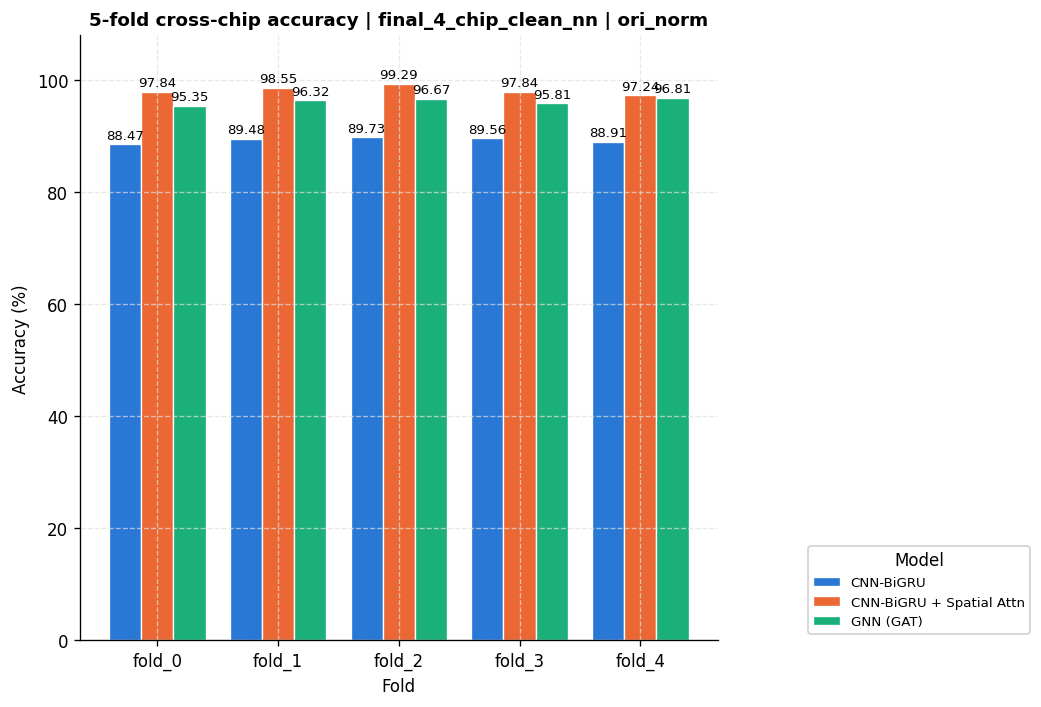

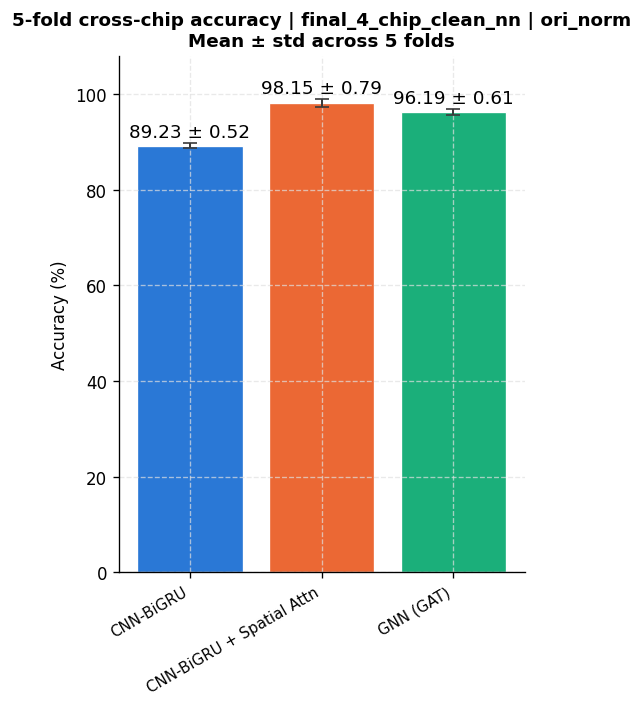


Mean ± std across folds (final_4_chip_clean_nn | ori_norm):
                          mean   std
model                               
cnn_gru_dual             89.23  0.52
cnn_gru_dual_attn_recon  98.15  0.79
gnn_gat                  96.19  0.61


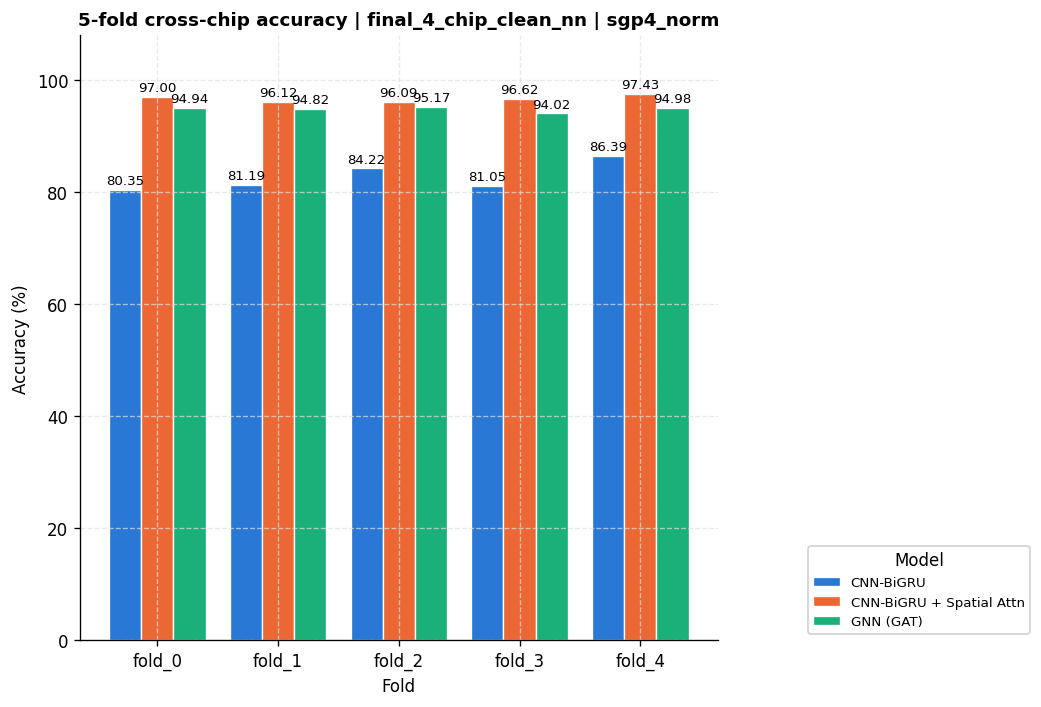

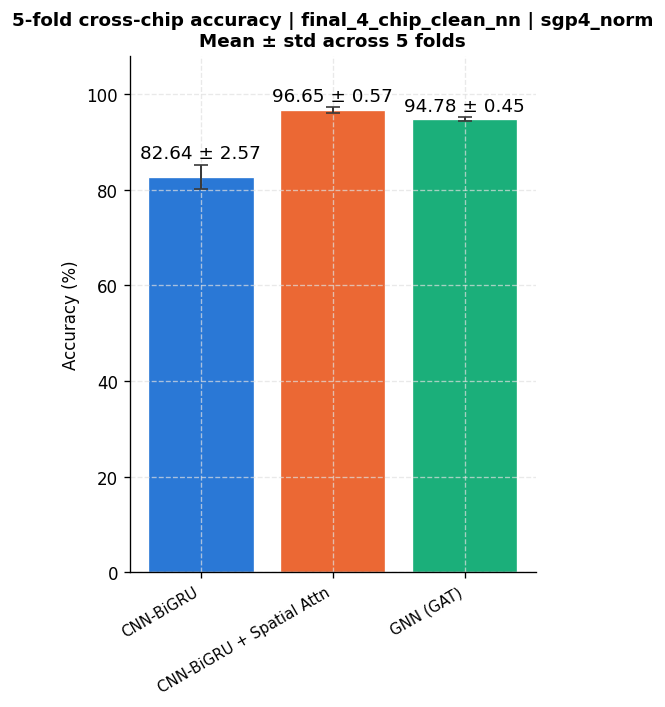


Mean ± std across folds (final_4_chip_clean_nn | sgp4_norm):
                          mean   std
model                               
cnn_gru_dual             82.64  2.57
cnn_gru_dual_attn_recon  96.65  0.57
gnn_gat                  94.78  0.45


In [26]:
%matplotlib inline

for (group_name, curve_type), sub in cv_df.groupby(['group', 'curve_type']):
    fold_labels = sorted(sub.fold.unique(), key=lambda s: int(s.split('_')[1]))
    stats = plot_grouped_bar_by_model(
        sub, x_col='fold', x_order=fold_labels, models=CV_MODELS, model_labels=FAMILY_LABELS,
        xlabel='Fold', title=f'5-fold cross-chip accuracy | {group_name} | {curve_type}',
    )
    print(f"\nMean ± std across folds ({group_name} | {curve_type}):")
    print(stats.round(2))


In [27]:
CV_MODELS

['cnn_gru_dual', 'cnn_gru_dual_attn_recon', 'gnn_gat']

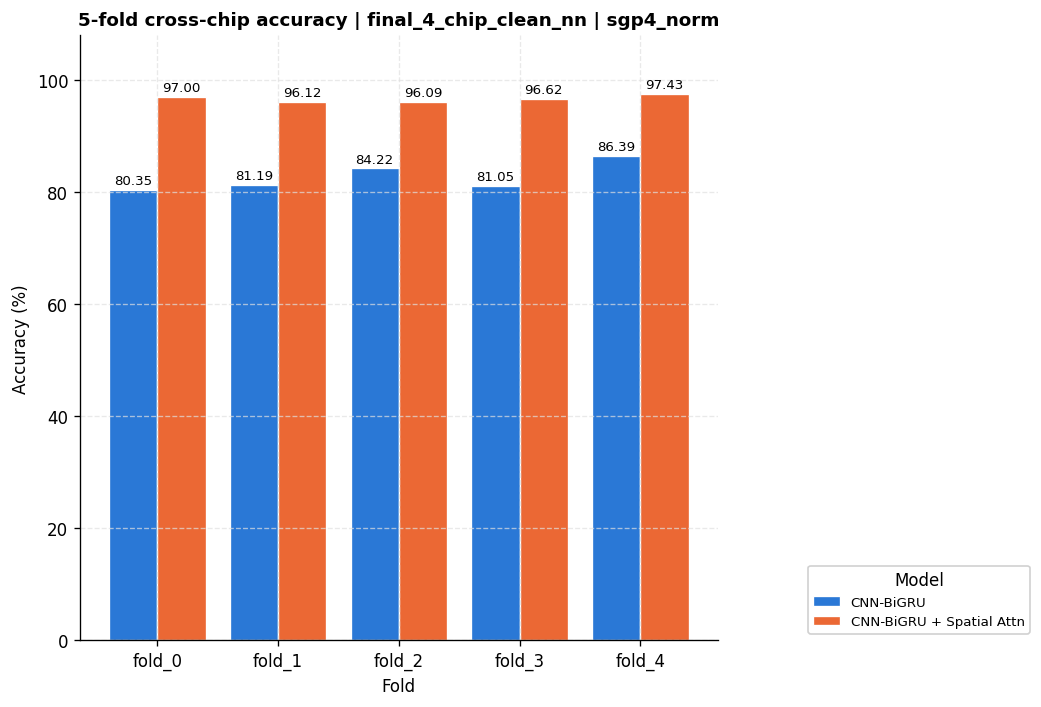

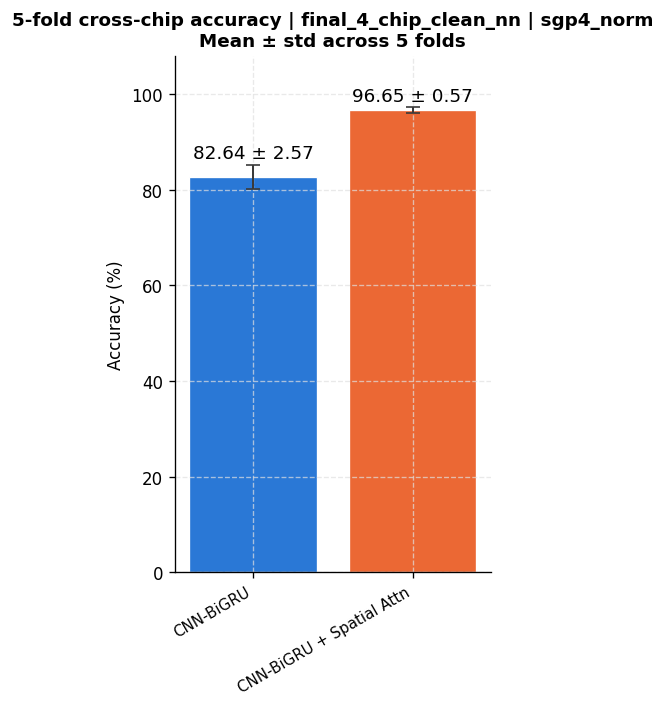

In [28]:
for (group_name, curve_type), sub in cv_df.groupby(['group', 'curve_type']):
    if(curve_type != 'sgp4_norm'):
        continue
    fold_labels = sorted(sub.fold.unique(), key=lambda s: int(s.split('_')[1]))
    stats = plot_grouped_bar_by_model(
        sub, x_col='fold', x_order=fold_labels, models=['cnn_gru_dual', 'cnn_gru_dual_attn_recon'], model_labels=FAMILY_LABELS,
        xlabel='Fold', title=f'5-fold cross-chip accuracy | {group_name} | {curve_type}',
    )
    # print(f"\nMean ± std across folds ({group_name} | {curve_type}):")
    # print(stats.round(2))

### LaTeX table -- CV (final_4_chip_clean_nn, SG p=4 norm), CNN-BiGRU vs. + Spatial Attn

Single table (one group/curve_type already, no per-dataset panels needed): rows = the
2 model variants, columns = Overall (Accuracy, F1) / Macro Averages (Sensitivity,
Specificity), each mean $\pm$ std across the 5 CV folds. GAT excluded per request.


In [29]:
def build_cv_latex_table(cv_df, group_name, curve_type, models, model_labels,
                          caption, label, bold_model=None):
    sub = cv_df[(cv_df.group == group_name) & (cv_df.curve_type == curve_type)
                & cv_df.model.isin(models)]
    metrics = ['accuracy', 'f1', 'sensitivity', 'specificity']
    stats = sub.groupby('model')[metrics].agg(['mean', 'std']).reindex(models)

    lines = [
        '\\begin{table}[htbp]',
        '    \\centering',
        f'    \\caption{{{caption}}}',
        f'    \\label{{{label}}}',
        '    \\small',
        '',
        '    \\resizebox{\\textwidth}{!}{',
        '    \\begin{tabular}{lrrrr}',
        '    \\toprule',
        '     & \\multicolumn{2}{c}{\\textbf{Overall}} & \\multicolumn{2}{c}{\\textbf{Macro Averages}} \\\\',
        '    \\cmidrule(lr){2-3} \\cmidrule(lr){4-5}',
        '    \\textbf{Model} & \\textbf{Accuracy} & \\textbf{F1} & \\textbf{Sensitivity} & \\textbf{Specificity} \\\\',
        '    \\midrule',
    ]
    for model in models:
        cells = [f"{stats.loc[model, (m, 'mean')]:.2f}\\% $\\pm$ {stats.loc[model, (m, 'std')]:.2f}\\%"
                 for m in metrics]
        row_label = model_labels.get(model, model).replace('\n', ' ')
        if model == bold_model:
            row_label = f'\\textbf{{{row_label}}}'
            cells = [f'\\textbf{{{c}}}' for c in cells]
        lines.append(f'    {row_label} & {" & ".join(cells)} \\\\')
    lines += ['    \\bottomrule', '    \\end{tabular}', '    }', '\\end{table}']
    return '\n'.join(lines)


cv_latex = build_cv_latex_table(
    cv_df, group_name='final_4_chip_clean_nn', curve_type='sgp4_norm',
    models=['cnn_gru_dual', 'cnn_gru_dual_attn_recon'], model_labels=FAMILY_LABELS,
    bold_model='cnn_gru_dual_attn_recon',
    caption=('5-fold cross-chip validation performance on final\\_4\\_chip\\_clean\\_nn '
             '(SG p=4, normalized), reported as mean $\\pm$ standard deviation across folds. '
             'The proposed model is shown in bold.'),
    label='tab:cv_final4_clean_nn_sgp4norm',
)
print(cv_latex)


\begin{table}[htbp]
    \centering
    \caption{5-fold cross-chip validation performance on final\_4\_chip\_clean\_nn (SG p=4, normalized), reported as mean $\pm$ standard deviation across folds. The proposed model is shown in bold.}
    \label{tab:cv_final4_clean_nn_sgp4norm}
    \small

    \resizebox{\textwidth}{!}{
    \begin{tabular}{lrrrr}
    \toprule
     & \multicolumn{2}{c}{\textbf{Overall}} & \multicolumn{2}{c}{\textbf{Macro Averages}} \\
    \cmidrule(lr){2-3} \cmidrule(lr){4-5}
    \textbf{Model} & \textbf{Accuracy} & \textbf{F1} & \textbf{Sensitivity} & \textbf{Specificity} \\
    \midrule
    CNN-BiGRU & 82.64\% $\pm$ 2.57\% & 82.17\% $\pm$ 2.85\% & 82.09\% $\pm$ 2.97\% & 95.57\% $\pm$ 0.67\% \\
    \textbf{CNN-BiGRU + Spatial Attn} & \textbf{96.65\% $\pm$ 0.57\%} & \textbf{97.03\% $\pm$ 0.50\%} & \textbf{97.02\% $\pm$ 0.50\%} & \textbf{99.13\% $\pm$ 0.15\%} \\
    \bottomrule
    \end{tabular}
    }
\end{table}


In [30]:
# for (group_name, curve_type), sub in cv_df.groupby(['group', 'curve_type']):
#     fold_labels = sorted(sub.fold.unique(), key=lambda s: int(s.split('_')[1]))
#     stats = plot_grouped_bar_by_model(
#         sub, x_col='fold', x_order=fold_labels, models=CV_MODELS, model_labels=FAMILY_LABELS,
#         value_col='well_accuracy', xlabel='Fold',
#         title=f'5-fold cross-chip well-level accuracy | {group_name} | {curve_type}',
#     )
#     print(f"\nMean \u00b1 std well-level accuracy across folds ({group_name} | {curve_type}):")
#     print(stats.round(2))


# 3. RQ3.2: LOFO

In [31]:
p08   = importlib.import_module("08_cross_dataset_predict_new_chip")
vis07 = importlib.import_module("07_attribution_vis_all")
rio   = importlib.import_module("cross_dataset_result_io")

import tensorflow as tf
tf.config.optimizer.set_jit(False)

LOFO_MODE_STR      = "lofo"
LOFO_CURVE_ALIGN   = "pc_ttp"
LOFO_PC_TTP_ANCHOR = "min"
LOFO_FRAC          = None
LOFO_FILTER        = "noamp_remove"
# LOFO_CURVE_TYPES   = ["ori_curve_norm", "ori_curve_wavelet_bior35_norm"]
# LOFO_CURVE_SHORT   = {"ori_curve_norm": "ori_norm", "ori_curve_wavelet_bior35_norm": "bior35_norm"}
LOFO_CURVE_TYPES = ["ori_curve_norm", "ori_curve_sg_p4_norm"]
LOFO_CURVE_SHORT = {"ori_curve_norm": "ori_norm", "ori_curve_sg_p4_norm": "sgp4_norm"}

COMPARISON_1 = ["cnn_gru_dual", "cnn_gru_dual_supcon3", "cnn_gru_dual_dann", "cnn_gru_dual_coral"]
COMPARISON_2 = ["cnn_gru_dual_attn_recon", "cnn_gru_dual_attn_recon_supcon","cnn_gru_dual_attn_recon_supcon3",
                "cnn_gru_dual_attn_recon_dann", "cnn_gru_dual_attn_recon_coral"]
COMPARISON_3 = ["gnn_gat", "gnn_gat_supcon3", "gnn_gat_dann", "gnn_gat_coral"]
LOFO_COMPARISON_1 = COMPARISON_1 + ["cnn_gru_dual_pc_recenter"]
LOFO_COMPARISON_2 = COMPARISON_2 + ["cnn_gru_dual_attn_recon_pc_recenter"]
LOFO_COMPARISON_3 = COMPARISON_3  # no pc_recenter variant for gnn_gat yet -- see load_lofo_accuracy

def lofo_group_dir(group_name):
    return b06.alignment_dir(cv_group_dir(group_name), LOFO_CURVE_ALIGN, LOFO_PC_TTP_ANCHOR)

def load_lofo_results(group_name, curve_type):
    out_dir = lofo_group_dir(group_name)
    legacy_path = b06.find_results_path(out_dir, LOFO_MODE_STR, curve_type)
    return b06.load_partitioned(out_dir, LOFO_MODE_STR, curve_type, legacy_path=legacy_path)

In [32]:
LOFO_CURVE_TYPES

['ori_curve_norm', 'ori_curve_sg_p4_norm']

In [33]:
PC_RECENTER_CACHE_NAME = "pc_recenter_sweep_cache.joblib"

def _pc_cache_path(group_name):
    return Path(CV_EXP_FOLDER) / "cross_dataset_cv" / group_name / PC_RECENTER_CACHE_NAME

def load_pc_cache(group_name):
    path = _pc_cache_path(group_name)
    if not path.exists():
        return {}
    try:
        return joblib.load(path)
    except Exception:
        return {}

def save_pc_cache(group_name, cache):
    path = _pc_cache_path(group_name)
    path.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(cache, path, compress=3)

def _mtime(path):
    try:
        return path.stat().st_mtime
    except FileNotFoundError:
        return None

def pc_cache_signature(model_path, out_dir, curve_type, held_out_chip=None):
    align_dir = config.cross_dataset_alignment_dir(out_dir, held_out_chip)
    return (_mtime(model_path),
           _mtime(align_dir / config.CROSS_DATASET_RESAMPLER_PATH.format(curve_type=curve_type)),
           _mtime(align_dir / config.CROSS_DATASET_PC_TTP_RECIPE_PATH.format(curve_type=curve_type)))


In [34]:
def lofo_ground_truth(chip_name, Y_well_raw, class_names):
    mapping = config.LABEL_MAPPINGS[chip_name]
    y_true = np.array([mapping.get(w, w) for w in Y_well_raw])
    if class_names:
        cn = list(class_names)
        y_true = np.array([next((c for c in cn if y == c or y.startswith(c + '-') or c.startswith(y + '-')), y)
                           for y in y_true])
    return y_true


def lofo_pc_recenter_accuracy(group_name, curve_type, base_model, chip_path, exp_paths_all, class_names, cache):
    out_dir = lofo_group_dir(group_name)
    chip_name = chip_path.name
    fold_label = f"lofo_{chip_name}"
    model_dir = out_dir / "model_interpretation" / fold_label
    model_path = model_dir / f"{base_model}_{LOFO_FILTER}_{curve_type}{rio.frac_suffix(LOFO_FRAC)}_model.keras"
    if not model_path.exists():
        return None

    cache_key = (curve_type, LOFO_CURVE_ALIGN, LOFO_PC_TTP_ANCHOR, LOFO_FRAC, LOFO_FILTER, base_model, chip_name)
    sig = pc_cache_signature(model_path, out_dir, curve_type, held_out_chip=chip_name)
    cached = cache.get(cache_key)
    if cached is not None and cached["sig"] == sig:
        return cached["row"]

    align_result = p08.align_new_chip(chip_path, out_dir, curve_type, LOFO_CURVE_ALIGN, LOFO_PC_TTP_ANCHOR,
                                      group_name=group_name, held_out_chip=chip_name)
    if align_result is None:
        return None
    curves, resampler, Y_well_raw, pc_curves_aligned, coords, well_ids = align_result

    loaded = vis07.load_saved_models(model_dir, LOFO_FILTER, len(resampler.t_grid), curve_type=curve_type,
                                     model_names=[base_model], train_center_frac=LOFO_FRAC)
    if base_model not in loaded:
        return None
    model = loaded[base_model]
    if p08._is_spatial(base_model) and (coords is None or well_ids is None):
        return None

    y_true = lofo_ground_truth(chip_name, Y_well_raw, class_names)
    valid = y_true != "PC"
    exp_paths_train = [p for p in exp_paths_all if p.name != chip_name]

    probs_base, _ = p08.predict_new_chip(model, base_model, curves, coords, well_ids, pc_curves_aligned,
                                         exp_paths_train, out_dir, curve_type, LOFO_FILTER, LOFO_CURVE_ALIGN,
                                         pc_recenter=False, held_out_chip=chip_name)
    pred_base = np.array(class_names)[np.argmax(probs_base, axis=1)]
    acc_base = (pred_base[valid] == y_true[valid]).mean() if valid.any() else float('nan')

    acc_recenter = float('nan')
    try:
        probs_r, _ = p08.predict_new_chip(model, base_model, curves, coords, well_ids, pc_curves_aligned,
                                          exp_paths_train, out_dir, curve_type, LOFO_FILTER, LOFO_CURVE_ALIGN,
                                          pc_recenter=True, force_rerun=True, held_out_chip=chip_name)
        pred_r = np.array(class_names)[np.argmax(probs_r, axis=1)]
        acc_recenter = (pred_r[valid] == y_true[valid]).mean() if valid.any() else float('nan')
    except ValueError:
        pass   # no PC snapshot for this chip -- leave acc_recenter as NaN

    row = {"acc_baseline": acc_base * 100, "acc_pc_recenter": acc_recenter * 100, "n_pixels": int(valid.sum())}
    cache[cache_key] = {"sig": sig, "row": row}
    save_pc_cache(group_name, cache)

    del model, loaded
    tf.keras.backend.clear_session()
    return row


In [35]:
def _lofo_well_ids_for_chip(group_name, curve_type, chip_path, class_names):
    """noamp_remove-filtered, label-verified well_ids for one held-out chip's LOFO test set.
    Reuses align_new_chip() (same call lofo_pc_recenter_accuracy below makes) since it reads
    the SAME saved resampler/pc_ttp recipe 04_cross_dataset_training.py saved for this exact
    held-out chip -- its curve output is the held-out chip's own rows of the LOFO training
    pool, in the pool's original row order. noamp_remove is applied by hand (predict_new_chip
    doesn't do this itself -- see 08_cross_dataset_predict_new_chip.py's __main__ block) to
    match what evaluate_outlier_filters actually filtered res_entry down to. Labels not found
    in class_names (e.g. PC) are dropped, same as lofo_pc_recenter_accuracy's own `valid` mask
    below; verified_well_ids catches any remaining mismatch (e.g. the rare-class-drop
    evaluate_outlier_filters also applies) and skips well_accuracy rather than risk a wrong
    number."""
    out_dir = lofo_group_dir(group_name)
    chip_name = chip_path.name
    align_result = p08.align_new_chip(chip_path, out_dir, curve_type, LOFO_CURVE_ALIGN, LOFO_PC_TTP_ANCHOR,
                                      group_name=group_name, held_out_chip=chip_name)
    if align_result is None:
        return None
    curves, resampler, Y_well_raw, pc_curves_aligned, coords, well_ids = align_result
    if well_ids is None:
        print(f"  [!] {group_name}/{curve_type}/{chip_name}: no pixel_row_idx/pixel_col_idx metadata (well_ids unavailable) -- well_accuracy skipped.")
        return None

    keep = p08.cdt.is_amplifying_mask(curves)
    Y_well_raw, well_ids = Y_well_raw[keep], well_ids[keep]

    y_true_str = lofo_ground_truth(chip_name, Y_well_raw, class_names)
    label_to_idx = {c: i for i, c in enumerate(class_names)}
    valid = np.array([lbl in label_to_idx for lbl in y_true_str])
    y_true_int = np.array([label_to_idx.get(lbl, -1) for lbl in y_true_str])
    return y_true_int[valid], well_ids[valid]


def load_lofo_accuracy(groups=None, group_indices=None):
    if groups is None:
        if group_indices is not None:
            groups = [list(config.CROSS_DATASET_GROUPS)[i] for i in group_indices]
        else:
            groups = list(config.CROSS_DATASET_GROUPS)
    all_models = COMPARISON_1 + COMPARISON_2 + COMPARISON_3
    rows = []
    for group_name in groups:
        exp_paths_all = [Path(CV_EXP_FOLDER, name) for name in config.CROSS_DATASET_GROUPS[group_name]]
        pc_cache = None

        for curve_type in LOFO_CURVE_TYPES:
            lofo_results = load_lofo_results(group_name, curve_type)
            if not any(k != "full_data" for k in lofo_results):
                continue
            if pc_cache is None:
                pc_cache = load_pc_cache(group_name)

            for chip_path in exp_paths_all:
                fold_entry = lofo_results.get(f"lofo_{chip_path.name}", {})
                res_entry = fold_entry.get(LOFO_FILTER)
                class_names = fold_entry.get("class_names")
                fold = short_name(chip_path.name)

                if res_entry is not None:
                    y_true_full = np.concatenate(res_entry["y_trues_"])
                    # Prefer well_ids_test_ (saved directly by evaluate_outlier_filters -- see
                    # utils/model_training/model_utils.py) over replaying the split -- skips
                    # _lofo_well_ids_for_chip's align_new_chip() call entirely once present.
                    saved_well_ids = res_entry.get('well_ids_test_')
                    if saved_well_ids is not None:
                        well_ids_test = np.concatenate(saved_well_ids)
                    else:
                        well_ids_test = None
                        if class_names is not None:
                            try:
                                well_check = _lofo_well_ids_for_chip(group_name, curve_type, chip_path, class_names)
                            except Exception as e:
                                print(f"  [!] {group_name}/{curve_type}/{fold}: could not reconstruct well_ids ({e}) -- well_accuracy skipped.")
                                well_check = None
                            if well_check is not None:
                                well_ids_test = verified_well_ids(y_true_full, [well_check],
                                                                  context=f'{group_name}/{curve_type}/{fold}')

                    for model in all_models:
                        preds_key = config.MODEL_KEY_MAP.get(model, (None,))[0]
                        if preds_key is None or preds_key not in res_entry:
                            continue
                        y_pred = np.concatenate(res_entry[preds_key])
                        row = dict(group=group_name, curve_type=LOFO_CURVE_SHORT.get(curve_type, curve_type),
                                  fold=fold, model=model,
                                  accuracy=accuracy_score(y_true_full, y_pred) * 100, n_test=len(y_true_full),
                                  well_accuracy=np.nan, n_wells=np.nan)
                        if well_ids_test is not None:
                            well_acc, n_wells = well_level_accuracy(y_true_full, y_pred, well_ids_test)
                            row["well_accuracy"] = well_acc * 100
                            row["n_wells"] = n_wells
                        rows.append(row)

                if class_names is None:
                    continue
                for base_model in ("cnn_gru_dual", "cnn_gru_dual_attn_recon"):
                    result = lofo_pc_recenter_accuracy(group_name, curve_type, base_model, chip_path,
                                                       exp_paths_all, class_names, pc_cache)
                    if result is None:
                        continue
                    rows.append(dict(group=group_name, curve_type=LOFO_CURVE_SHORT.get(curve_type, curve_type),
                                     fold=fold, model=f"{base_model}_pc_recenter",
                                     accuracy=result["acc_pc_recenter"], n_test=result["n_pixels"]))
    return pd.DataFrame(rows)

lofo_df = load_lofo_accuracy(group_indices=[3, 5])
print(f"Loaded {len(lofo_df)} rows  |  "
      f"{lofo_df.group.nunique()} groups  "
      f"{lofo_df.curve_type.nunique()} curve types  "
      f"{lofo_df.fold.nunique()} folds  "
      f"{lofo_df.model.nunique()} models")
lofo_df.head(8)


  [*] LOFO_EXCLUDE_WELL_MAPPING['final_4_chip_clean_nn']: dropping 1135 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260806_E00_C00_F4500KHz_U_DDM_01_06
  [PC-TTP align] new chip TTP=332.81  anchor=79.67  shift=253.15
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_4_chip_cov_hadv_iav']: dropping 4963 samples from wells [3, 4, 8, 9] (y_label={3: 'IBV', 4: 'Kp', 8: 'PC', 9: 'NC-ALL'}, y_concentration={3: '1e+04', 4: '1e+05', 8: '0e+00', 9: '0e+00'}) for D20260806_E00_C00_F4500KHz_U_DDM_01_06
  [PC-TTP align] new chip TTP=332.81  anchor=79.67  shift=253.15
Loaded 141 rows  |  2 groups  2 curve types  4 folds  15 models


,group,curve_type,fold,model,accuracy,n_test,well_accuracy,n_wells
0,final_4_chip_clean_nn,ori_norm,DDM_01,cnn_gru_dual,34.190290,13264,42.857143,7.0
1,final_4_chip_clean_nn,ori_norm,DDM_01,cnn_gru_dual_supcon3,32.765380,13264,42.857143,7.0
2,final_4_chip_clean_nn,ori_norm,DDM_01,cnn_gru_dual_dann,36.293727,13264,42.857143,7.0
3,final_4_chip_clean_nn,ori_norm,DDM_01,cnn_gru_dual_coral,34.838661,13264,42.857143,7.0
4,final_4_chip_clean_nn,ori_norm,DDM_01,cnn_gru_dual_attn_recon,24.170688,13264,28.571429,7.0
5,final_4_chip_clean_nn,ori_norm,DDM_01,cnn_gru_dual_attn_recon_supcon3,31.951146,13264,28.571429,7.0
6,final_4_chip_clean_nn,ori_norm,DDM_01,cnn_gru_dual_attn_recon_dann,25.128166,13264,28.571429,7.0
7,final_4_chip_clean_nn,ori_norm,DDM_01,cnn_gru_dual_attn_recon_coral,12.002413,13264,0.000000,7.0


In [36]:
def lofo_completeness(df, comparison_models, label):
    check = (df[df.model.isin(comparison_models)]
               .groupby(['group', 'curve_type', 'fold'])
               .size()
               .reset_index(name='n')
               .assign(expected=len(comparison_models), ok=lambda x: x.n == x.expected))
    missing = check[~check.ok]
    if missing.empty:
        print(f"[{label}] All combinations fully populated.")
    else:
        print(f"[{label}] Incomplete combinations:")
        display(missing)

lofo_completeness(lofo_df, LOFO_COMPARISON_1, "Comparison 1 (cnn_gru_dual family)")
lofo_completeness(lofo_df, LOFO_COMPARISON_2, "Comparison 2 (cnn_gru_dual_attn_recon family)")
lofo_completeness(lofo_df, LOFO_COMPARISON_3, "Comparison 3 (gnn_gat family)")


[Comparison 1 (cnn_gru_dual family)] Incomplete combinations:


,group,curve_type,fold,n,expected,ok
1,final_4_chip_clean_nn,ori_norm,DDM_02,1,5,False


[Comparison 2 (cnn_gru_dual_attn_recon family)] Incomplete combinations:


,group,curve_type,fold,n,expected,ok
0,final_4_chip_clean_nn,ori_norm,DDM_01,5,6,False
5,final_4_chip_cov_hadv_iav,ori_norm,DDM_01,5,6,False


[Comparison 3 (gnn_gat family)] All combinations fully populated.


In [37]:
lofo_df.group.unique()

array(['final_4_chip_clean_nn', 'final_4_chip_cov_hadv_iav'], dtype=object)

In [38]:
LOFO_COMPARISON_2

['cnn_gru_dual_attn_recon',
 'cnn_gru_dual_attn_recon_supcon',
 'cnn_gru_dual_attn_recon_supcon3',
 'cnn_gru_dual_attn_recon_dann',
 'cnn_gru_dual_attn_recon_coral',
 'cnn_gru_dual_attn_recon_pc_recenter']

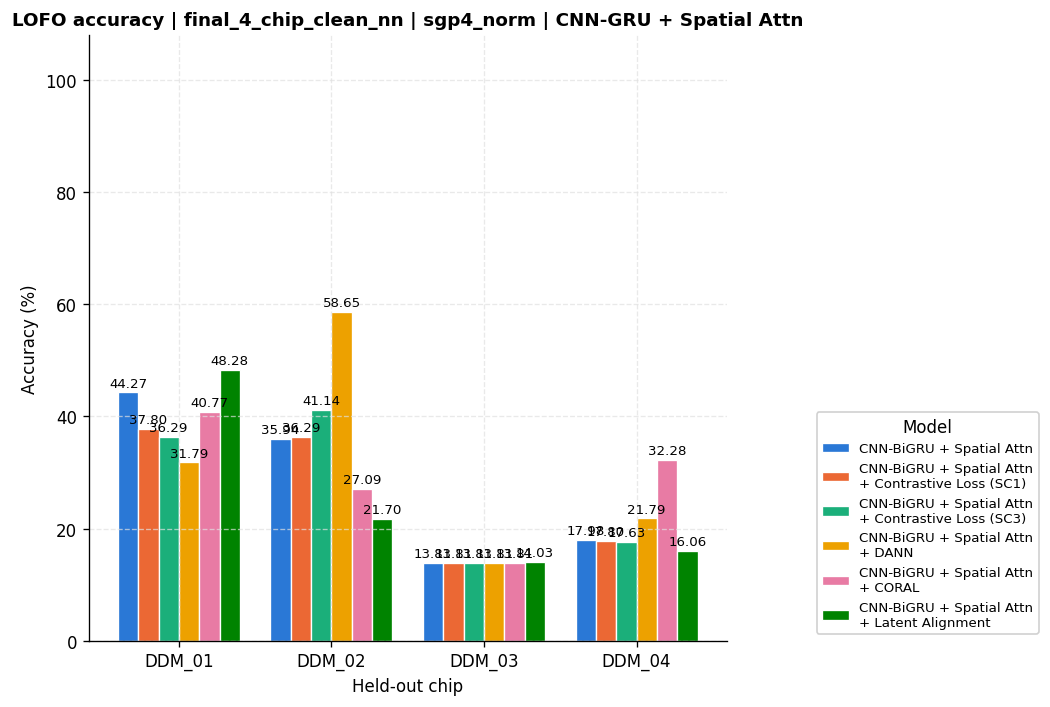

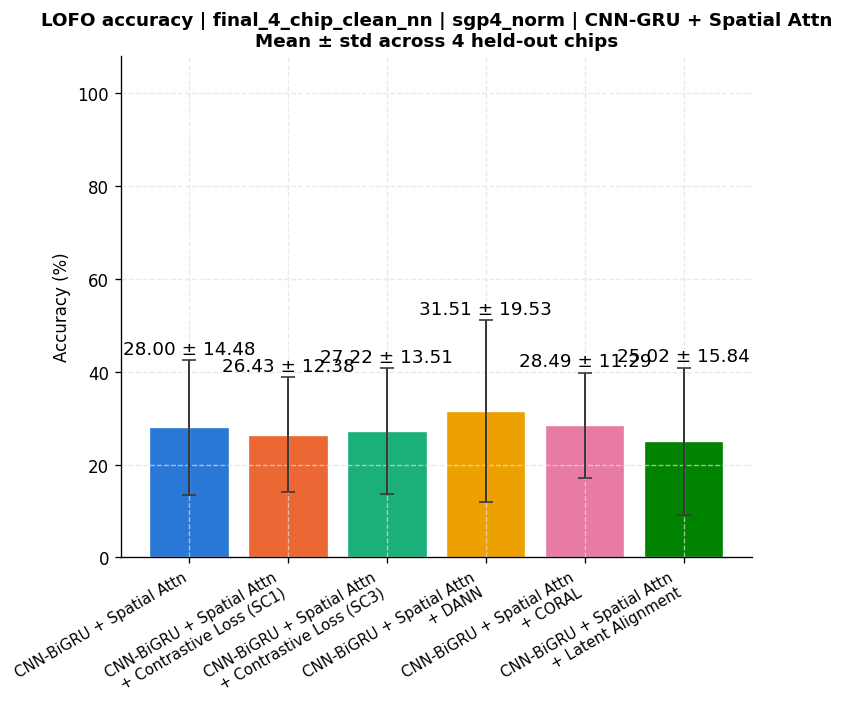

In [39]:
%matplotlib inline

# selected_held_outs = ['DDM_01']
selected_held_outs = []
if selected_held_outs:
    lofo_df_filtered = lofo_df[lofo_df['fold'].isin(selected_held_outs)].copy()
else:
    lofo_df_filtered = lofo_df.copy()

lofo_df_filtered = lofo_df_filtered[lofo_df_filtered['curve_type'] == 'sgp4_norm']
lofo_df_filtered = lofo_df_filtered[lofo_df_filtered['group'].isin(['final_4_chip_clean_nn'])]
# lofo_df_filtered = lofo_df_filtered[lofo_df_filtered['model'].isin(['cnn_gru_dual', 'cnn_gru_dual_attn_recon', 'cnn_gru_dual_attn_recon_pc_recenter'])]

for (group_name, curve_type), sub in lofo_df_filtered.groupby(['group', 'curve_type']):
    fold_labels = sorted(sub.fold.unique())
    for comparison, label in [(LOFO_COMPARISON_2, "CNN-GRU + Spatial Attn")]:
        comp_sub = sub[sub.model.isin(comparison)]
        if comp_sub.empty:
            continue
        stats = plot_grouped_bar_by_model(
            comp_sub, x_col='fold', x_order=fold_labels, models=comparison, model_labels=FAMILY_LABELS,
            xlabel='Held-out chip', title=f'LOFO accuracy | {group_name} | {curve_type} | {label}',
            plot_fold=True, plot_summary=True, show_std=True,
        )
        # print(f"\nMean ± std across held-out chips ({group_name} | {curve_type} | {label}):")
        # print(stats.round(2))
    print("="*70)


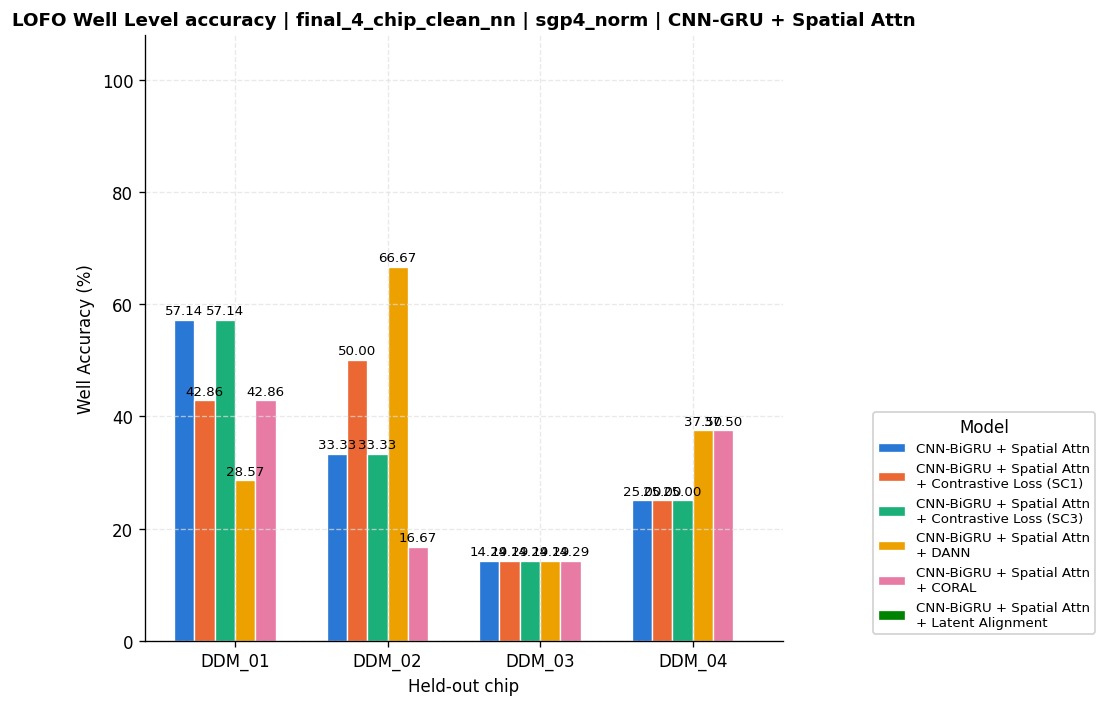

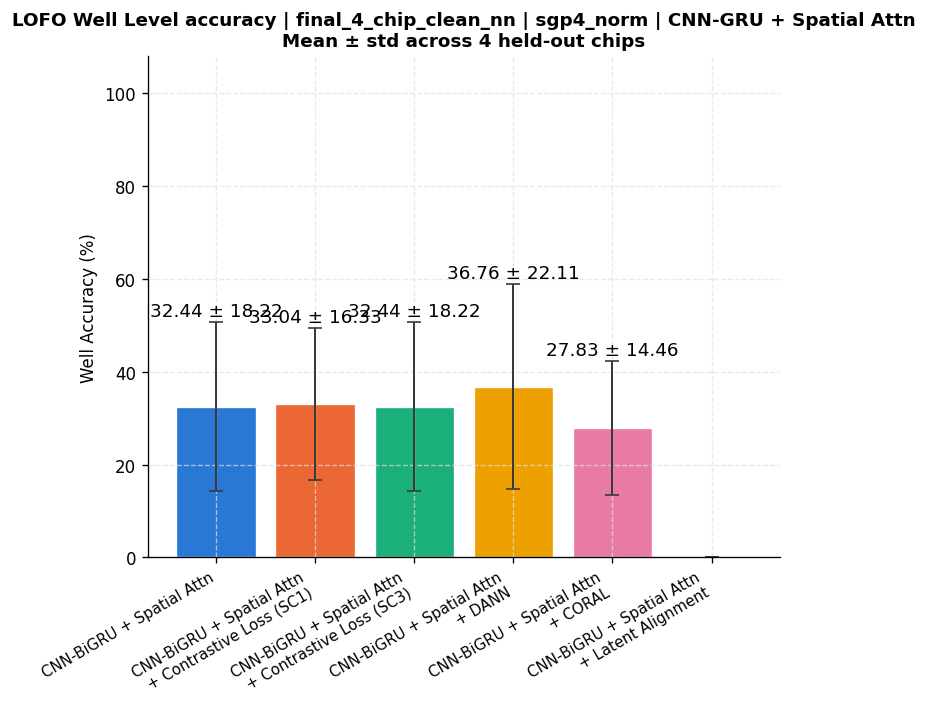

In [40]:
%matplotlib inline

# selected_held_outs = ['DDM_01']
selected_held_outs = []
if selected_held_outs:
    lofo_df_filtered = lofo_df[lofo_df['fold'].isin(selected_held_outs)].copy()
else:
    lofo_df_filtered = lofo_df.copy()

lofo_df_filtered = lofo_df_filtered[lofo_df_filtered['curve_type'] == 'sgp4_norm']
lofo_df_filtered = lofo_df_filtered[lofo_df_filtered['group'].isin(['final_4_chip_clean_nn'])]
# lofo_df_filtered = lofo_df_filtered[lofo_df_filtered['model'].isin(['cnn_gru_dual', 'cnn_gru_dual_attn_recon', 'cnn_gru_dual_attn_recon_pc_recenter'])]

for (group_name, curve_type), sub in lofo_df_filtered.groupby(['group', 'curve_type']):
    fold_labels = sorted(sub.fold.unique())
    for comparison, label in [(LOFO_COMPARISON_2, "CNN-GRU + Spatial Attn")]:
        comp_sub = sub[sub.model.isin(comparison)]
        if comp_sub.empty:
            continue
        stats = plot_grouped_bar_by_model(
            comp_sub, x_col='fold', x_order=fold_labels, models=comparison, model_labels=FAMILY_LABELS,
            xlabel='Held-out chip', title=f'LOFO Well Level accuracy | {group_name} | {curve_type} | {label}',
            value_col='well_accuracy',
            plot_fold=True, plot_summary=True, show_std=True,
        )
        # print(f"\nMean ± std across held-out chips ({group_name} | {curve_type} | {label}):")
        # print(stats.round(2))
    print("="*70)


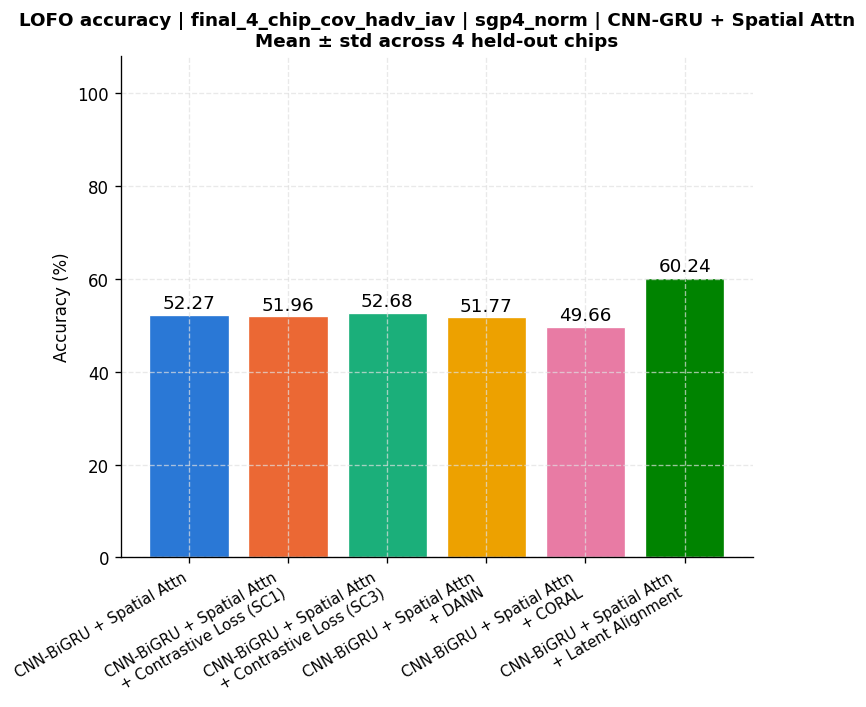

In [41]:
%matplotlib inline

# selected_held_outs = ['DDM_01']
selected_held_outs = []
if selected_held_outs:
    lofo_df_filtered = lofo_df[lofo_df['fold'].isin(selected_held_outs)].copy()
else:
    lofo_df_filtered = lofo_df.copy()

lofo_df_filtered = lofo_df_filtered[lofo_df_filtered['curve_type'] == 'sgp4_norm']
lofo_df_filtered = lofo_df_filtered[lofo_df_filtered['group'].isin(['final_4_chip_cov_hadv_iav'])]
# lofo_df_filtered = lofo_df_filtered[lofo_df_filtered['model'].isin(['cnn_gru_dual', 'cnn_gru_dual_attn_recon', 'cnn_gru_dual_attn_recon_pc_recenter'])]

for (group_name, curve_type), sub in lofo_df_filtered.groupby(['group', 'curve_type']):
    fold_labels = sorted(sub.fold.unique())
    for comparison, label in [(LOFO_COMPARISON_2, "CNN-GRU + Spatial Attn")]:
        comp_sub = sub[sub.model.isin(comparison)]
        if comp_sub.empty:
            continue
        stats = plot_grouped_bar_by_model(
            comp_sub, x_col='fold', x_order=fold_labels, models=comparison, model_labels=FAMILY_LABELS,
            xlabel='Held-out chip', title=f'LOFO accuracy | {group_name} | {curve_type} | {label}',
            plot_fold=False, plot_summary=True, show_std=False,
        )
        # print(f"\nMean ± std across held-out chips ({group_name} | {curve_type} | {label}):")
        # print(stats.round(2))
    print("="*70)


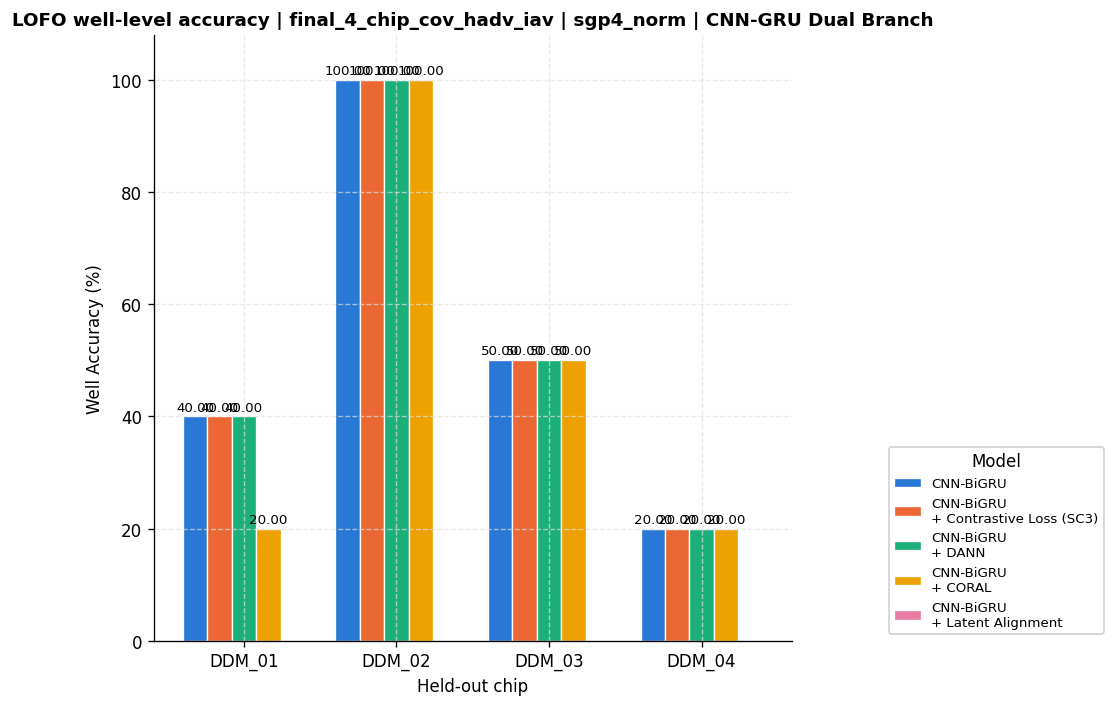

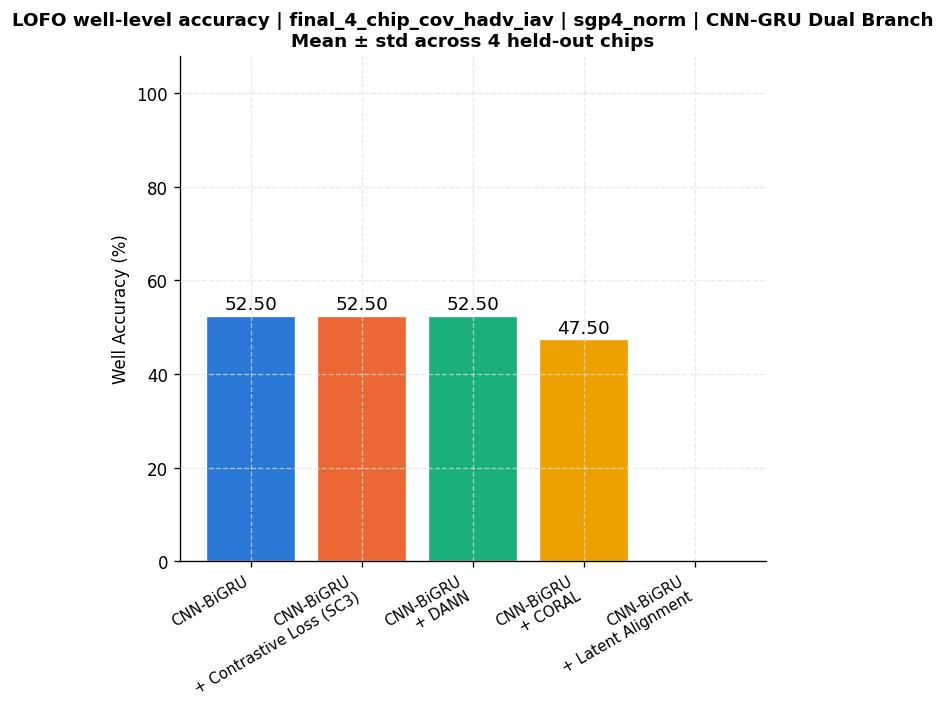

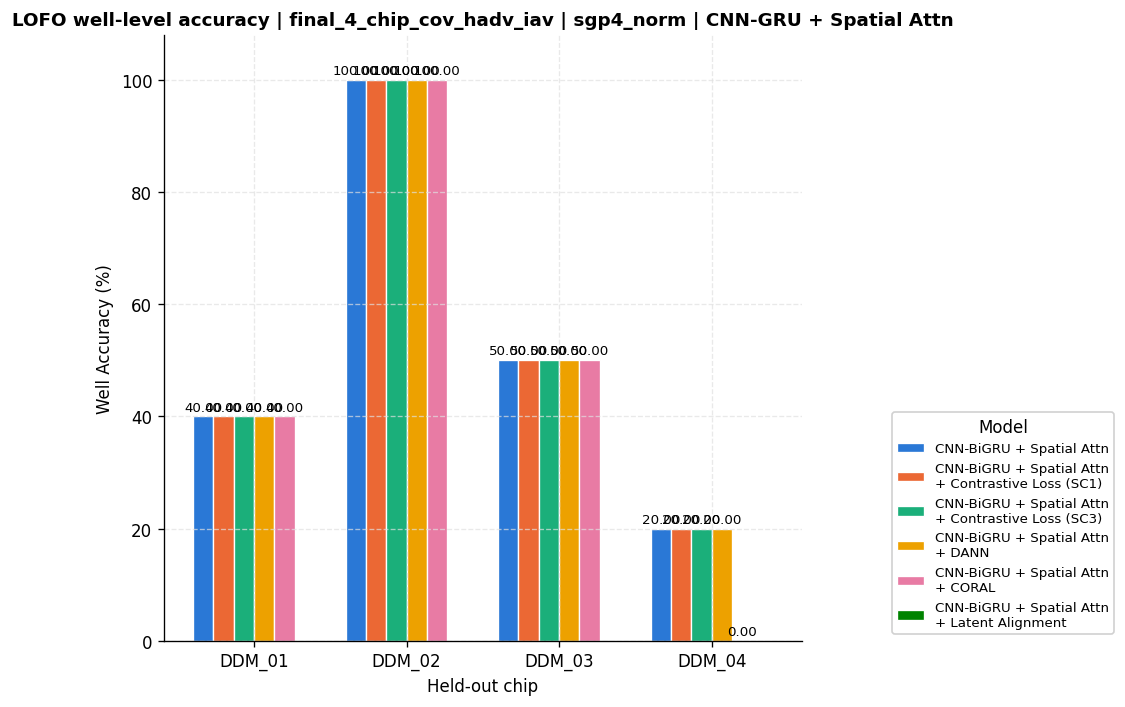

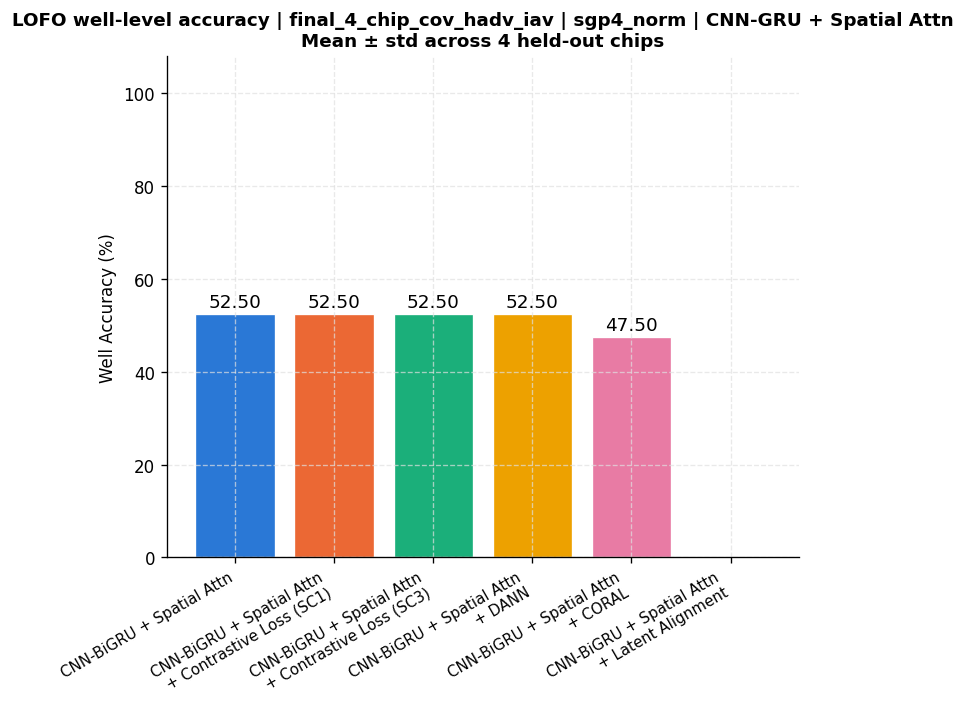

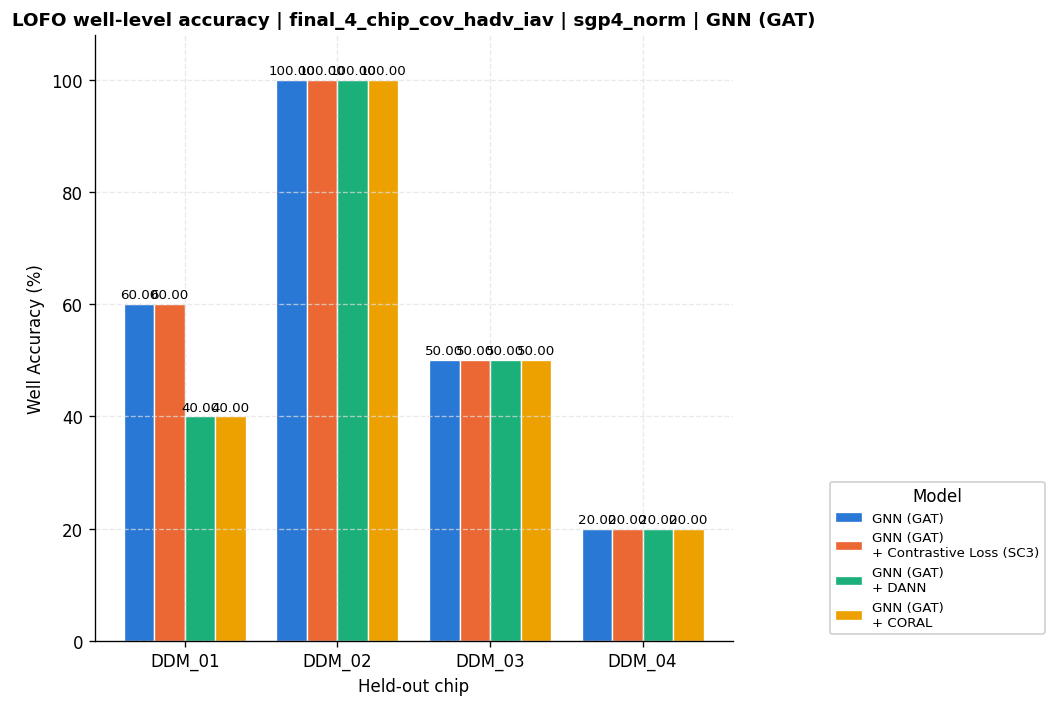

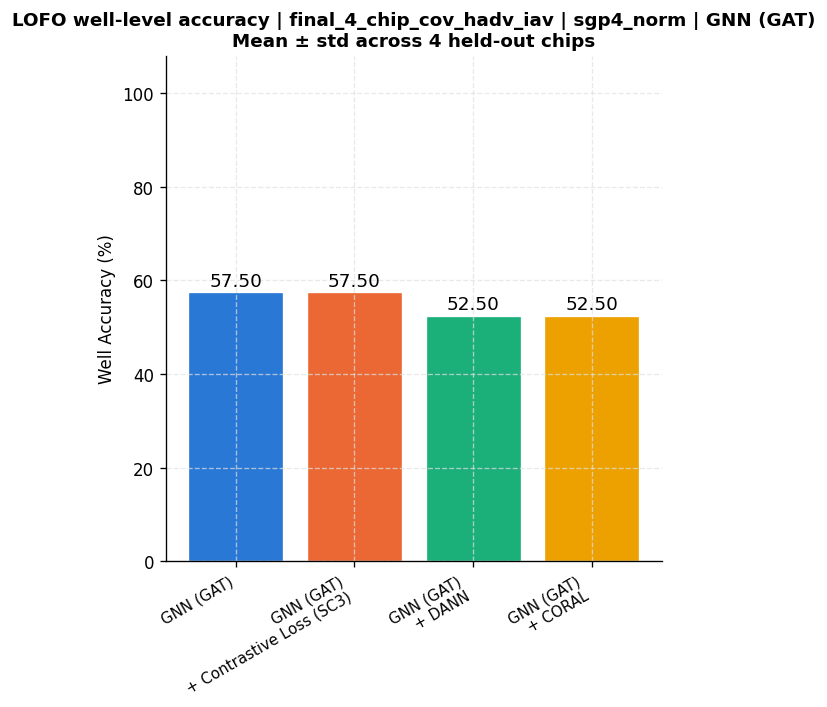

In [42]:
for (group_name, curve_type), sub in lofo_df_filtered.groupby(['group', 'curve_type']):
    fold_labels = sorted(sub.fold.unique())
    for comparison, label in [(LOFO_COMPARISON_1, "CNN-GRU Dual Branch"),
                              (LOFO_COMPARISON_2, "CNN-GRU + Spatial Attn"),
                              (LOFO_COMPARISON_3, "GNN (GAT)")]:
        comp_sub = sub[sub.model.isin(comparison)]
        if comp_sub.empty:
            continue
        stats = plot_grouped_bar_by_model(
            comp_sub, x_col='fold', x_order=fold_labels, models=comparison, model_labels=FAMILY_LABELS,
            value_col='well_accuracy', xlabel='Held-out chip',
            title=f'LOFO well-level accuracy | {group_name} | {curve_type} | {label}',
            plot_fold=True, plot_summary=True, show_std=False,
        )
    print("="*70)
